In [ ]:
!pip -q install fair-esm biopython scikit-learn matplotlib pandas requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.1 MB/s eta 0:00:00


In [ ]:
import io
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

import torch
import esm

In [ ]:
def fetch_uniprot_fasta(uniprot_id: str):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    record = next(SeqIO.parse(io.StringIO(r.text), "fasta"))
    return str(record.seq), record.description

tp53_seq, tp53_desc = fetch_uniprot_fasta("P04637")

print(tp53_desc)
print("Length:", len(tp53_seq))
print(tp53_seq[:80] + "...")

sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
Length: 393
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAP...


In [ ]:
# Actualización de nombres de grupos para que sean más descriptivos
position_groups = {
    "Hotspots canónicos": [175, 220, 245, 248],
    "Estructurales": [176, 179, 249, 282],
    "Comparativos del DBD": [125, 138, 151, 157],
}

all_positions = []
for group, pos_list in position_groups.items():
    for p in pos_list:
        all_positions.append((p, group))

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

print("Grupos actualizados:", position_groups.keys())

Grupos actualizados: dict_keys(['Hotspots canónicos', 'Estructurales', 'Comparativos del DBD'])


In [ ]:
for pos, group in all_positions:
    wt_aa = tp53_seq[pos - 1]
    print(f"{group:15s} {wt_aa}{pos}")

Hotspots canónicos R175
Hotspots canónicos Y220
Hotspots canónicos G245
Hotspots canónicos R248
Estructurales   C176
Estructurales   H179
Estructurales   R249
Estructurales   R282
Comparativos del DBD T125
Comparativos del DBD A138
Comparativos del DBD P151
Comparativos del DBD V157


In [ ]:
def generate_single_mutants_with_metadata(seq, positions_with_groups, amino_acids):
    mutants = []
    seq_list = list(seq)

    for pos_1based, group in positions_with_groups:
        idx = pos_1based - 1
        wt_aa = seq_list[idx]

        for aa in amino_acids:
            if aa == wt_aa:
                continue

            mut_seq = seq_list.copy()
            mut_seq[idx] = aa
            mut_seq = "".join(mut_seq)

            mutants.append({
                "mutant": f"{wt_aa}{pos_1based}{aa}",
                "position": pos_1based,
                "wt_aa": wt_aa,
                "mut_aa": aa,
                "group": group,
                "sequence": mut_seq,
            })

    return mutants

mutants = generate_single_mutants_with_metadata(tp53_seq, all_positions, amino_acids)

print("Number of mutants:", len(mutants))
pd.DataFrame(mutants).head()

Number of mutants: 228


,mutant,position,wt_aa,mut_aa,group,sequence
0,R175A,175,R,A,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
1,R175C,175,R,C,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
2,R175D,175,R,D,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
3,R175E,175,R,E,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
4,R175F,175,R,F,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

#model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
#model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
#model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()



batch_converter = alphabet.get_batch_converter()

model.eval()
model = model.to(device)

Device: cuda
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt


In [ ]:
def get_residue_representations_batched(
    seqs_with_names,
    model,
    batch_converter,
    device="cpu",
    repr_layer=33,
    batch_size=16
):
    all_labels = []
    all_residue_reps = []

    for start in range(0, len(seqs_with_names), batch_size):
        batch = seqs_with_names[start:start + batch_size]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch)
        batch_tokens = batch_tokens.to(device)

        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[repr_layer], return_contacts=False)

        token_representations = results["representations"][repr_layer]

        for i, seq in enumerate(batch_strs):
            reps = token_representations[i, 1:len(seq)+1].cpu().numpy()  # (L, d)
            all_labels.append(batch_labels[i])
            all_residue_reps.append(reps)

    return all_labels, all_residue_reps


def global_embedding_from_residue_matrix(residue_matrix):
    return residue_matrix.mean(axis=0)


def local_window_embedding(residue_matrix, pos_1based, k=5):
    idx = pos_1based - 1
    left = max(0, idx - k)
    right = min(residue_matrix.shape[0], idx + k + 1)
    return residue_matrix[left:right].mean(axis=0)


def residue_only_embedding(residue_matrix, pos_1based):
    idx = pos_1based - 1
    return residue_matrix[idx]

In [ ]:
all_sequences = [("WT", tp53_seq)] + [(m["mutant"], m["sequence"]) for m in mutants]

labels, residue_reps = get_residue_representations_batched(
    all_sequences,
    model=model,
    batch_converter=batch_converter,
    device=device,
    repr_layer=33,
    batch_size=64,
)

print("Number of sequences:", len(labels))
print("Residue matrix shape for WT:", residue_reps[0].shape)

Number of sequences: 229
Residue matrix shape for WT: (393, 1280)


In [ ]:
wt_emb = global_embedding_from_residue_matrix(residue_reps[0])
print("Global embedding matrix shape:", wt_emb.shape)

Global embedding matrix shape: (1280,)


In [ ]:
global_emb = np.vstack([global_embedding_from_residue_matrix(x) for x in residue_reps])
print("Global embedding matrix shape:", global_emb.shape)

Global embedding matrix shape: (229, 1280)


In [ ]:
k5_emb = np.vstack([wt_emb]+[local_window_embedding(x, m["position"], k=5) for x, m in zip(residue_reps, mutants)])
print("Local k=5 embedding matrix shape:", k5_emb.shape)

Local k=5 embedding matrix shape: (229, 1280)


In [ ]:
wt_residue_reps = residue_reps[0]
wt_global_emb = global_embedding_from_residue_matrix(wt_residue_reps).reshape(1, -1)

results = []

for i, m in enumerate(mutants, start=1):
    mut_residue_reps = residue_reps[i]
    pos = m["position"]

    # Global
    mut_global_emb = global_embedding_from_residue_matrix(mut_residue_reps).reshape(1, -1)
    global_cos_sim = cosine_similarity(mut_global_emb, wt_global_emb)[0, 0]
    global_cos_dist = 1.0 - global_cos_sim
    global_euc_dist = euclidean_distances(mut_global_emb, wt_global_emb)[0, 0]

    # Local k=0
    wt_k0 = residue_only_embedding(wt_residue_reps, pos).reshape(1, -1)
    mut_k0 = residue_only_embedding(mut_residue_reps, pos).reshape(1, -1)
    k0_cos_sim = cosine_similarity(mut_k0, wt_k0)[0, 0]
    k0_cos_dist = 1.0 - k0_cos_sim
    k0_euc_dist = euclidean_distances(mut_k0, wt_k0)[0, 0]

    # Local k=3
    wt_k3 = local_window_embedding(wt_residue_reps, pos, k=3).reshape(1, -1)
    mut_k3 = local_window_embedding(mut_residue_reps, pos, k=3).reshape(1, -1)
    k3_cos_sim = cosine_similarity(mut_k3, wt_k3)[0, 0]
    k3_cos_dist = 1.0 - k3_cos_sim
    k3_euc_dist = euclidean_distances(mut_k3, wt_k3)[0, 0]

    # Local k=5
    wt_k5 = local_window_embedding(wt_residue_reps, pos, k=5).reshape(1, -1)
    mut_k5 = local_window_embedding(mut_residue_reps, pos, k=5).reshape(1, -1)
    k5_cos_sim = cosine_similarity(mut_k5, wt_k5)[0, 0]
    k5_cos_dist = 1.0 - k5_cos_sim
    k5_euc_dist = euclidean_distances(mut_k5, wt_k5)[0, 0]

    results.append({
        "mutant": m["mutant"],
        "position": m["position"],
        "wt_aa": m["wt_aa"],
        "mut_aa": m["mut_aa"],
        "group": m["group"],

        "global_cosine_similarity_to_WT": float(global_cos_sim),
        "global_cosine_distance_to_WT": float(global_cos_dist),
        "global_euclidean_distance_to_WT": float(global_euc_dist),

        "k0_cosine_similarity_to_WT": float(k0_cos_sim),
        "k0_cosine_distance_to_WT": float(k0_cos_dist),
        "k0_euclidean_distance_to_WT": float(k0_euc_dist),

        "k3_cosine_similarity_to_WT": float(k3_cos_sim),
        "k3_cosine_distance_to_WT": float(k3_cos_dist),
        "k3_euclidean_distance_to_WT": float(k3_euc_dist),

        "k5_cosine_similarity_to_WT": float(k5_cos_sim),
        "k5_cosine_distance_to_WT": float(k5_cos_dist),
        "k5_euclidean_distance_to_WT": float(k5_euc_dist),
    })

df = pd.DataFrame(results)
df.head()

,mutant,position,wt_aa,mut_aa,group,global_cosine_similarity_to_WT,global_cosine_distance_to_WT,global_euclidean_distance_to_WT,k0_cosine_similarity_to_WT,k0_cosine_distance_to_WT,k0_euclidean_distance_to_WT,k3_cosine_similarity_to_WT,k3_cosine_distance_to_WT,k3_euclidean_distance_to_WT,k5_cosine_similarity_to_WT,k5_cosine_distance_to_WT,k5_euclidean_distance_to_WT
0,R175A,175,R,A,Hotspots canónicos,0.999950,0.000050,0.086051,0.886312,0.113688,4.545448,0.990167,0.009833,1.085244,0.993308,0.006692,0.896670
1,R175C,175,R,C,Hotspots canónicos,0.999968,0.000032,0.071122,0.905606,0.094394,4.142328,0.990641,0.009359,1.089417,0.994134,0.005866,0.868803
2,R175D,175,R,D,Hotspots canónicos,0.999926,0.000074,0.104173,0.876742,0.123258,4.744982,0.985677,0.014323,1.320025,0.990228,0.009772,1.091273
3,R175E,175,R,E,Hotspots canónicos,0.999918,0.000082,0.110315,0.882806,0.117194,4.637805,0.987850,0.012150,1.214584,0.991417,0.008583,1.021816
4,R175F,175,R,F,Hotspots canónicos,0.999963,0.000037,0.075071,0.889230,0.110770,4.495902,0.989462,0.010538,1.115325,0.993290,0.006710,0.896999


In [ ]:
metric_cols = [
    "global_cosine_distance_to_WT",
    "k0_cosine_distance_to_WT",
    "k3_cosine_distance_to_WT",
    "k5_cosine_distance_to_WT",
]

df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
global_cosine_distance_to_WT,228.0,0.000026,0.000016,0.000004,0.000014,0.000022,0.000035,0.000082
k0_cosine_distance_to_WT,228.0,0.064621,0.021963,0.012552,0.051029,0.060694,0.079024,0.124642
k3_cosine_distance_to_WT,228.0,0.005495,0.002815,0.001513,0.003547,0.005097,0.006896,0.017042
k5_cosine_distance_to_WT,228.0,0.003311,0.001867,0.000793,0.001949,0.003016,0.004108,0.010893


In [ ]:
df_metric_comparison = df[metric_cols].describe().T
df_metric_comparison['metric'] = df_metric_comparison.index
df_metric_comparison = df_metric_comparison.reset_index(drop=True)
df_metric_comparison = df_metric_comparison[['metric', 'mean', 'std', 'min', '50%', 'max']]
df_metric_comparison["metric"] = df_metric_comparison["metric"].str.replace("_", " ")
df_metric_comparison['mean'].round()
df_metric_comparison.to_csv("metric_comparison.csv", index=False,float_format='%.2f')
df_metric_comparison["metric"] = ["Global", "k0", "k3", "k5"]

df_metric_comparison

,metric,mean,std,min,50%,max
0,Global,0.000026,0.000016,0.000004,0.000022,0.000082
1,k0,0.064621,0.021963,0.012552,0.060694,0.124642
2,k3,0.005495,0.002815,0.001513,0.005097,0.017042
3,k5,0.003311,0.001867,0.000793,0.003016,0.010893


In [ ]:
df_metric_comparison.to_csv("metric_comparison.csv", index=False)

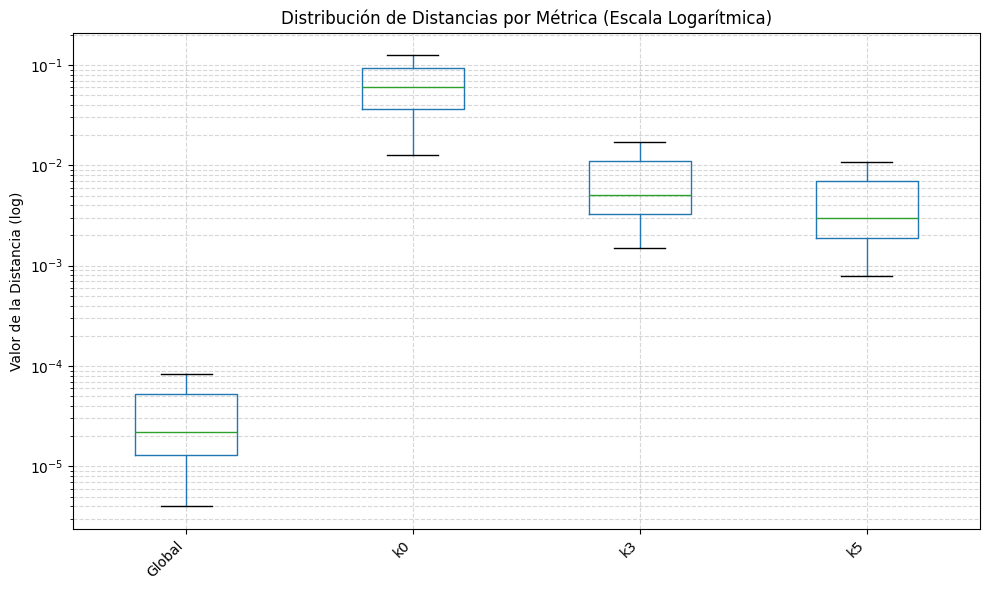

In [ ]:

plt.figure(figsize=(10, 6))
df_metric_comparison.set_index('metric')[['min', '50%', 'max']].T.boxplot()
plt.yscale('log')
plt.title('Distribución de Distancias por Métrica (Escala Logarítmica)')
plt.ylabel('Valor de la Distancia (log)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("metric_comparison_boxplot.svg")
plt.show()

In [ ]:
for col in metric_cols:
    print("=" * 80)
    print(col)
    display(
        df.sort_values(col, ascending=False)[
            ["mutant", "position", "group", col]
        ].head(10)
    )

global_cosine_distance_to_WT


,mutant,position,group,global_cosine_distance_to_WT
3,R175E,175,Hotspots canónicos,0.000082
62,R248G,248,Hotspots canónicos,0.000077
119,R249G,249,Estructurales,0.000075
116,R249D,249,Estructurales,0.000075
2,R175D,175,Hotspots canónicos,0.000074
136,R282E,282,Estructurales,0.000064
45,G245K,245,Hotspots canónicos,0.000060
57,R248A,248,Hotspots canónicos,0.000059
71,R248S,248,Hotspots canónicos,0.000059
51,G245R,245,Hotspots canónicos,0.000059


k0_cosine_distance_to_WT


,mutant,position,group,k0_cosine_distance_to_WT
95,H179A,179,Estructurales,0.124642
2,R175D,175,Hotspots canónicos,0.123258
3,R175E,175,Hotspots canónicos,0.117194
100,H179G,179,Estructurales,0.114180
0,R175A,175,Hotspots canónicos,0.113688
16,R175V,175,Hotspots canónicos,0.111780
14,R175S,175,Hotspots canónicos,0.111735
4,R175F,175,Hotspots canónicos,0.110770
108,H179R,179,Estructurales,0.108073
46,G245L,245,Hotspots canónicos,0.107703


k3_cosine_distance_to_WT


,mutant,position,group,k3_cosine_distance_to_WT
49,G245P,245,Hotspots canónicos,0.017042
38,G245A,245,Hotspots canónicos,0.014754
2,R175D,175,Hotspots canónicos,0.014323
46,G245L,245,Hotspots canónicos,0.014087
62,R248G,248,Hotspots canónicos,0.013791
3,R175E,175,Hotspots canónicos,0.012150
9,R175L,175,Hotspots canónicos,0.011855
192,P151D,151,Comparativos del DBD,0.011584
12,R175P,175,Hotspots canónicos,0.011504
16,R175V,175,Hotspots canónicos,0.011240


k5_cosine_distance_to_WT


,mutant,position,group,k5_cosine_distance_to_WT
49,G245P,245,Hotspots canónicos,0.010893
38,G245A,245,Hotspots canónicos,0.010316
2,R175D,175,Hotspots canónicos,0.009772
46,G245L,245,Hotspots canónicos,0.009524
3,R175E,175,Hotspots canónicos,0.008583
62,R248G,248,Hotspots canónicos,0.008129
9,R175L,175,Hotspots canónicos,0.007739
12,R175P,175,Hotspots canónicos,0.007518
54,G245V,245,Hotspots canónicos,0.007258
16,R175V,175,Hotspots canónicos,0.007193


In [ ]:
summary_by_position = (
    df.groupby(["group", "position", "wt_aa"], as_index=False)
      .agg(
          n_mutants=("mutant", "count"),

          global_mean=("global_cosine_distance_to_WT", "mean"),
          global_median=("global_cosine_distance_to_WT", "median"),
          global_std=("global_cosine_distance_to_WT", "std"),
          global_max=("global_cosine_distance_to_WT", "max"),

          k0_mean=("k0_cosine_distance_to_WT", "mean"),
          k0_median=("k0_cosine_distance_to_WT", "median"),
          k0_std=("k0_cosine_distance_to_WT", "std"),
          k0_max=("k0_cosine_distance_to_WT", "max"),

          k3_mean=("k3_cosine_distance_to_WT", "mean"),
          k3_median=("k3_cosine_distance_to_WT", "median"),
          k3_std=("k3_cosine_distance_to_WT", "std"),
          k3_max=("k3_cosine_distance_to_WT", "max"),

          k5_mean=("k5_cosine_distance_to_WT", "mean"),
          k5_median=("k5_cosine_distance_to_WT", "median"),
          k5_std=("k5_cosine_distance_to_WT", "std"),
          k5_max=("k5_cosine_distance_to_WT", "max"),
      )
)

summary_by_position["site"] = summary_by_position["wt_aa"] + summary_by_position["position"].astype(str)
summary_by_position.sort_values("k5_mean", ascending=False)

,group,position,wt_aa,n_mutants,global_mean,global_median,global_std,global_max,k0_mean,k0_median,...,k0_max,k3_mean,k3_median,k3_std,k3_max,k5_mean,k5_median,k5_std,k5_max,site
8,Hotspots canónicos,175,R,19,0.000038,0.000037,0.000019,0.000082,0.094656,0.103086,...,0.123258,0.008721,0.009359,0.003231,0.014323,0.005653,0.005882,0.002282,0.009772,R175
10,Hotspots canónicos,245,G,19,0.000037,0.000034,0.000013,0.000060,0.076796,0.080284,...,0.107703,0.008374,0.007789,0.003785,0.017042,0.005360,0.004852,0.002625,0.010893,G245
2,Comparativos del DBD,151,P,19,0.000016,0.000016,0.000004,0.000023,0.073129,0.074005,...,0.095086,0.006940,0.006962,0.001760,0.011584,0.003985,0.003968,0.001028,0.006592,P151
11,Hotspots canónicos,248,R,19,0.000045,0.000048,0.000017,0.000077,0.062540,0.065000,...,0.090978,0.006781,0.006544,0.003091,0.013791,0.003871,0.003676,0.001817,0.008129,R248
4,Estructurales,176,C,19,0.000018,0.000019,0.000005,0.000028,0.041985,0.042475,...,0.074205,0.005978,0.006184,0.001525,0.008537,0.003630,0.003736,0.000897,0.005112,C176
5,Estructurales,179,H,19,0.000018,0.000017,0.000008,0.000032,0.079293,0.088513,...,0.124642,0.005789,0.006752,0.002264,0.009757,0.003302,0.003689,0.001334,0.005616,H179
7,Estructurales,282,R,19,0.000029,0.000029,0.000013,0.000064,0.066255,0.069540,...,0.089448,0.004621,0.005036,0.001272,0.006377,0.003233,0.003422,0.001016,0.005077,R282
3,Comparativos del DBD,157,V,19,0.000029,0.000033,0.000010,0.000046,0.071375,0.074062,...,0.097253,0.004776,0.004214,0.001321,0.007354,0.002761,0.002555,0.000845,0.004417,V157
6,Estructurales,249,R,19,0.000041,0.000041,0.000018,0.000075,0.047737,0.052284,...,0.069458,0.004322,0.004209,0.002037,0.010174,0.002720,0.002637,0.001406,0.006937,R249
9,Hotspots canónicos,220,Y,19,0.000018,0.000018,0.000006,0.000029,0.052617,0.055182,...,0.068493,0.003537,0.003617,0.001026,0.005322,0.001909,0.001900,0.000649,0.003006,Y220


In [ ]:
mutants_df = pd.DataFrame(mutants)
labels_df = pd.DataFrame(labels, columns=["label"])
group_list = [m["group"] for m in mutants]
group_list.append("WT")


Shape embeddings: (229, 1280)
Número de labels: 229


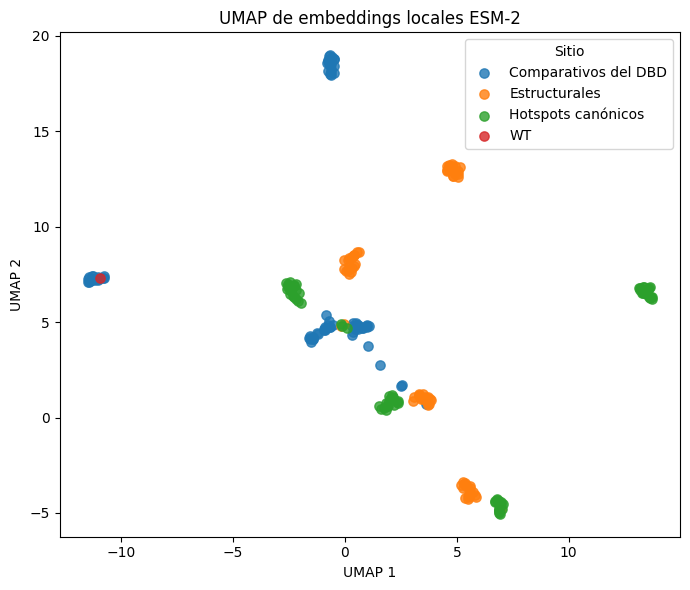

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

from sklearn.preprocessing import StandardScaler


# =========================
# 1. Revisar dimensiones
# =========================

X = global_emb
labels = group_list

print("Shape embeddings:", X.shape)
print("Número de labels:", len(labels))

assert X.shape[0] == len(labels), "El número de embeddings y labels no coincide"


# =========================
# 2. Escalar embeddings
# =========================

X_scaled = StandardScaler().fit_transform(X)


# =========================
# 3. Calcular UMAP
# =========================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
)

X_umap = reducer.fit_transform(X_scaled)


# =========================
# 4. Pasar a dataframe
# =========================

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels,
})


# =========================
# 5. Graficar por label
# =========================

plt.figure(figsize=(7, 6))

for label in np.unique(labels):
    subset = df_umap[df_umap["label"] == label]
    plt.scatter(
        subset["UMAP1"],
        subset["UMAP2"],
        label=label,
        alpha=0.8,
        s=45,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP de embeddings locales ESM-2")
plt.legend(title="Sitio")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


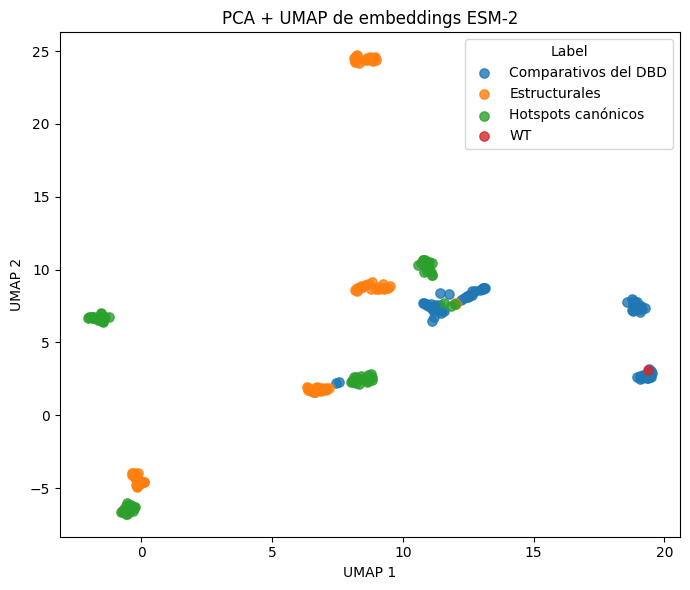

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap


X_scaled = StandardScaler().fit_transform(X)

X_pca = PCA(n_components=50, random_state=42).fit_transform(X_scaled)

X_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
).fit_transform(X_pca)

# =========================
# 4. Pasar a dataframe
# =========================

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels,
})


# =========================
# 5. Graficar por label
# =========================

plt.figure(figsize=(7, 6))

for label in np.unique(labels):
    subset = df_umap[df_umap["label"] == label]
    plt.scatter(
        subset["UMAP1"],
        subset["UMAP2"],
        label=label,
        alpha=0.8,
        s=45,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("PCA + UMAP de embeddings ESM-2")
plt.legend(title="Label")
plt.tight_layout()
plt.show()


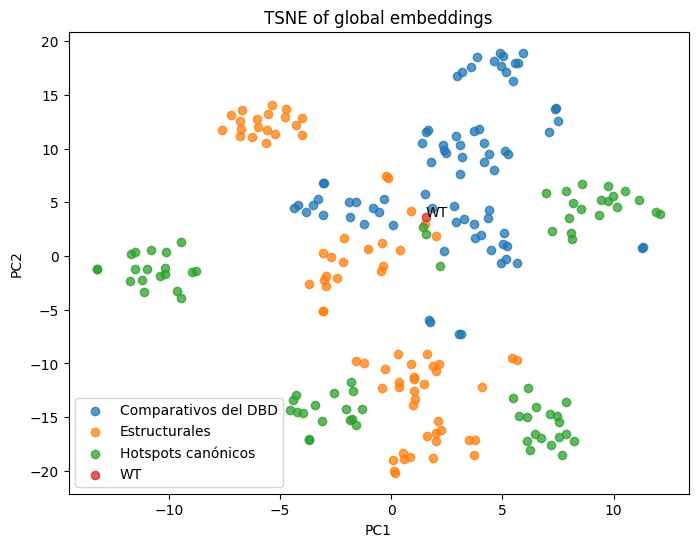

In [ ]:

from sklearn.manifold import TSNE


coords = TSNE(n_components=2).fit_transform(global_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in np.unique(labels):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("TSNE of global embeddings")
plt.legend()
plt.savefig("tsne-global-embeddings.svg")
plt.show()

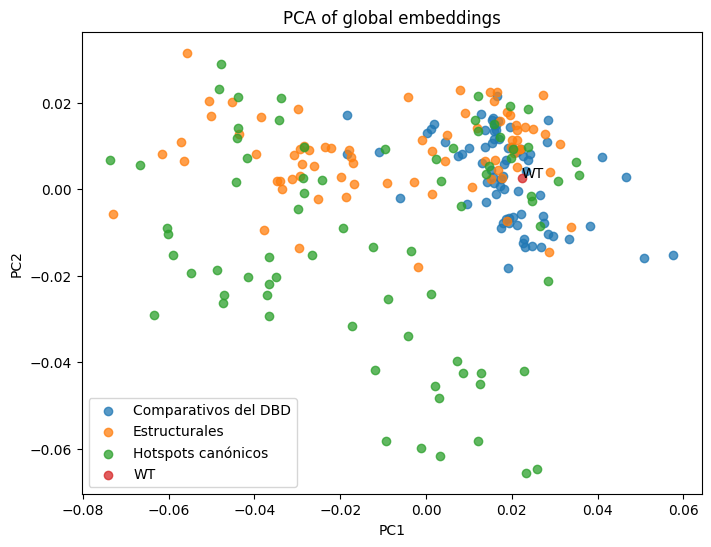

In [ ]:
pca = PCA(n_components=2)
coords = pca.fit_transform(global_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in np.unique(labels):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of global embeddings")
plt.legend()
plt.savefig("pca-global-embeddings.svg")
plt.show()

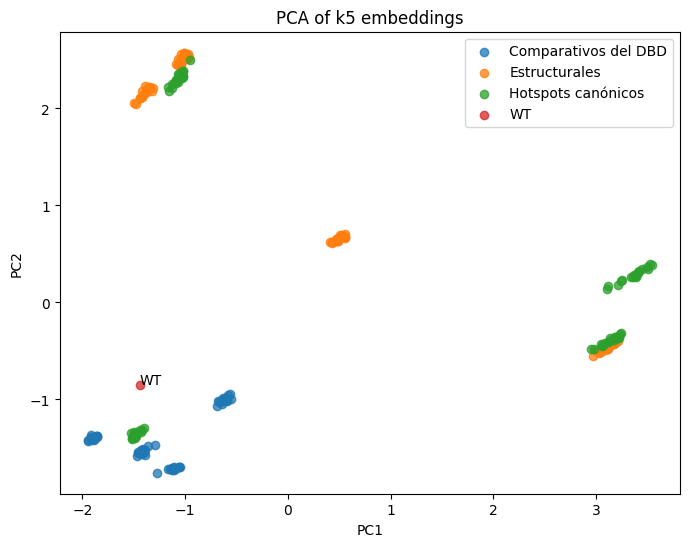

In [ ]:
## Proyeccion de k5

pca = PCA(n_components=2)
coords = pca.fit_transform(k5_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in np.unique(labels):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of k5 embeddings")
plt.legend()
plt.savefig("pca-k5-embeddings.svg")
plt.show()

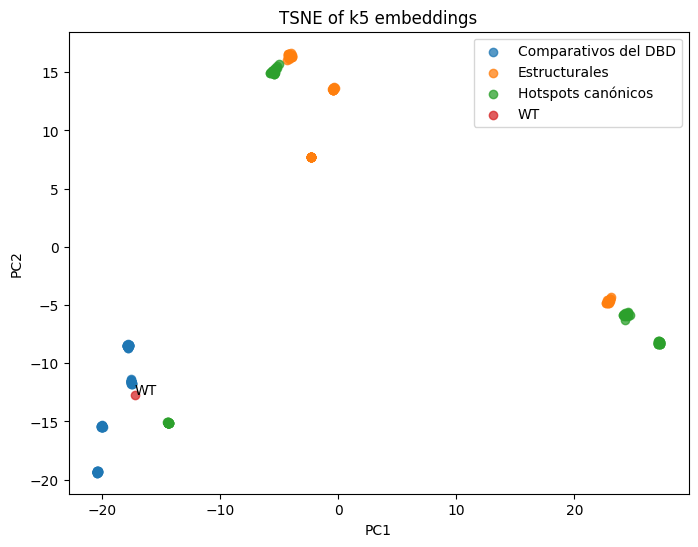

In [ ]:
coords = TSNE(n_components=2,metric='cosine').fit_transform(k5_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in np.unique(labels):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("TSNE of k5 embeddings")
plt.legend()
plt.savefig("tsne-k5-embeddings.svg")
plt.show()

In [ ]:

# =========================
# 1. Revisar dimensiones
# =========================

X = k5_emb
labels = group_list

print("Shape embeddings:", X.shape)
print("Número de labels:", len(labels))

assert X.shape[0] == len(labels), "El número de embeddings y labels no coincide"


# =========================
# 2. Escalar embeddings
# =========================

X_scaled = StandardScaler().fit_transform(X)


# =========================
# 3. Calcular UMAP
# =========================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
)

X_umap = reducer.fit_transform(X_scaled)


# =========================
# 4. Pasar a dataframe
# =========================

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels,
})


# =========================
# 5. Graficar por label
# =========================


Shape embeddings: (229, 1280)
Número de labels: 229


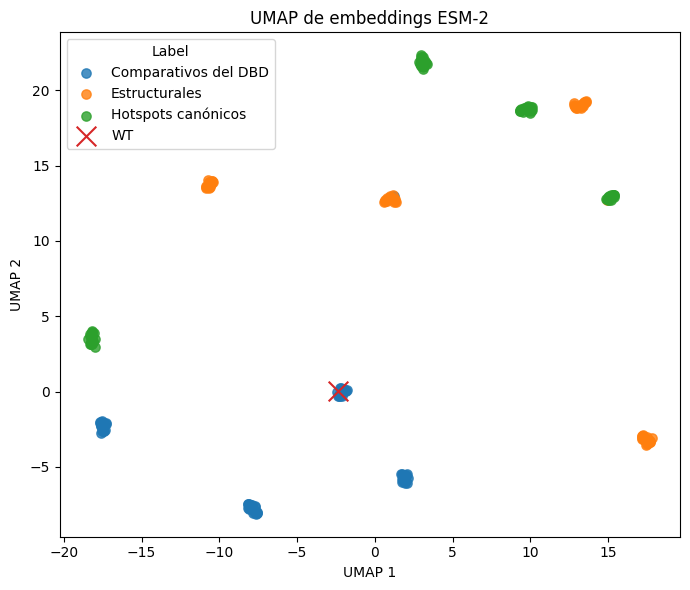

In [ ]:

plt.figure(figsize=(7, 6))

for label in np.unique(labels):
    subset = df_umap[df_umap["label"] == label]
    if label == "WT":
        plt.scatter(
            subset["UMAP1"],
            subset["UMAP2"],
            label=label,
            alpha=1.0,
            s=200,
            marker="x"
        )
    else:
      plt.scatter(
          subset["UMAP1"],
          subset["UMAP2"],
          label=label,
          alpha=0.8,
          s=45,
      )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP de embeddings ESM-2")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

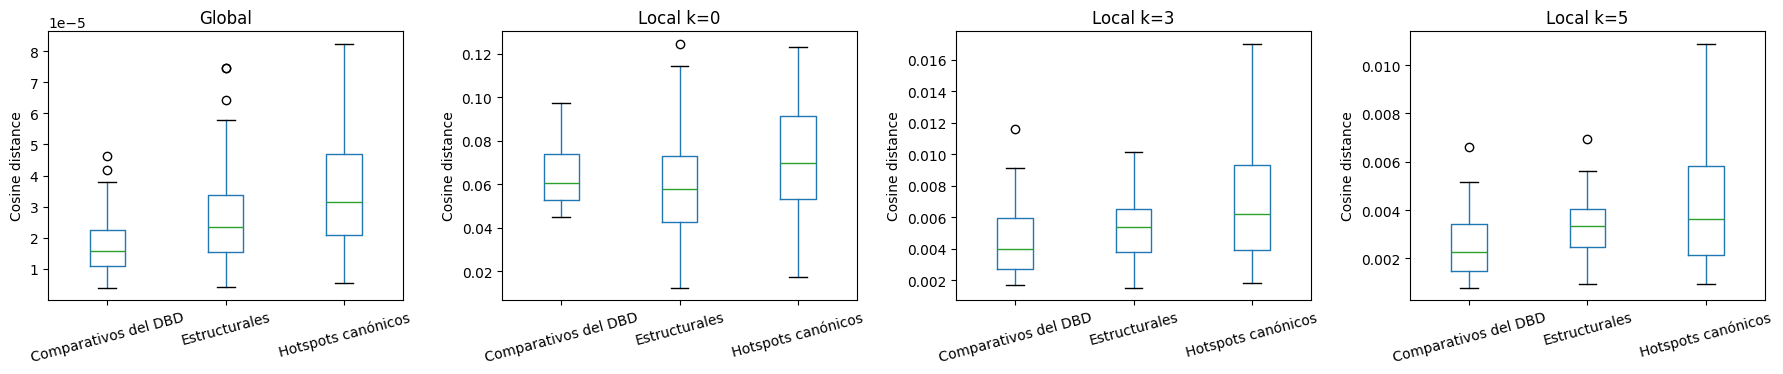

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

plot_map = [
    ("global_cosine_distance_to_WT", "Global"),
    ("k0_cosine_distance_to_WT", "Local k=0"),
    ("k3_cosine_distance_to_WT", "Local k=3"),
    ("k5_cosine_distance_to_WT", "Local k=5"),
]

for ax, (col, title) in zip(axes, plot_map):
    df.boxplot(column=col, by="group", grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Cosine distance")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("")
plt.tight_layout()
plt.show()

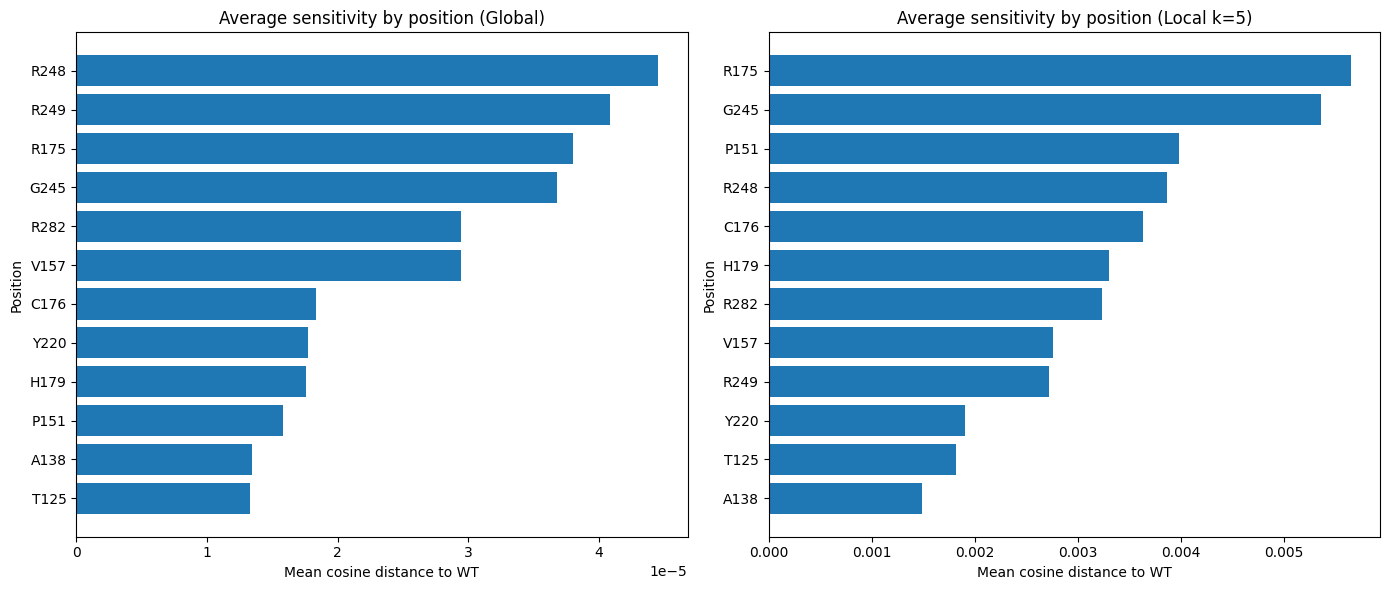

In [ ]:
rank_global = summary_by_position.sort_values("global_mean", ascending=False)[["site", "global_mean"]].reset_index(drop=True)
rank_k5 = summary_by_position.sort_values("k5_mean", ascending=False)[["site", "k5_mean"]].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tmp = summary_by_position.sort_values("global_mean", ascending=True)
axes[0].barh(tmp["site"], tmp["global_mean"])
axes[0].set_title("Average sensitivity by position (Global)")
axes[0].set_xlabel("Mean cosine distance to WT")
axes[0].set_ylabel("Position")

tmp = summary_by_position.sort_values("k5_mean", ascending=True)
axes[1].barh(tmp["site"], tmp["k5_mean"])
axes[1].set_title("Average sensitivity by position (Local k=5)")
axes[1].set_xlabel("Mean cosine distance to WT")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.savefig("average-sensitivity-by-position-global-vs-k5.svg")
plt.show()

In [ ]:
compare_rank = summary_by_position[["site", "group", "global_mean", "k5_mean"]].copy()
compare_rank["delta_k5_minus_global"] = compare_rank["k5_mean"] - compare_rank["global_mean"]
compare_rank = compare_rank.sort_values("delta_k5_minus_global", ascending=False)

compare_rank

,site,group,global_mean,k5_mean,delta_k5_minus_global
8,R175,Hotspots canónicos,0.000038,0.005653,0.005615
10,G245,Hotspots canónicos,0.000037,0.005360,0.005323
2,P151,Comparativos del DBD,0.000016,0.003985,0.003969
11,R248,Hotspots canónicos,0.000045,0.003871,0.003826
4,C176,Estructurales,0.000018,0.003630,0.003612
5,H179,Estructurales,0.000018,0.003302,0.003285
7,R282,Estructurales,0.000029,0.003233,0.003203
3,V157,Comparativos del DBD,0.000029,0.002761,0.002732
6,R249,Estructurales,0.000041,0.002720,0.002679
9,Y220,Hotspots canónicos,0.000018,0.001909,0.001891


In [ ]:
compare_rank.to_csv("compare_rank.csv", index=False)



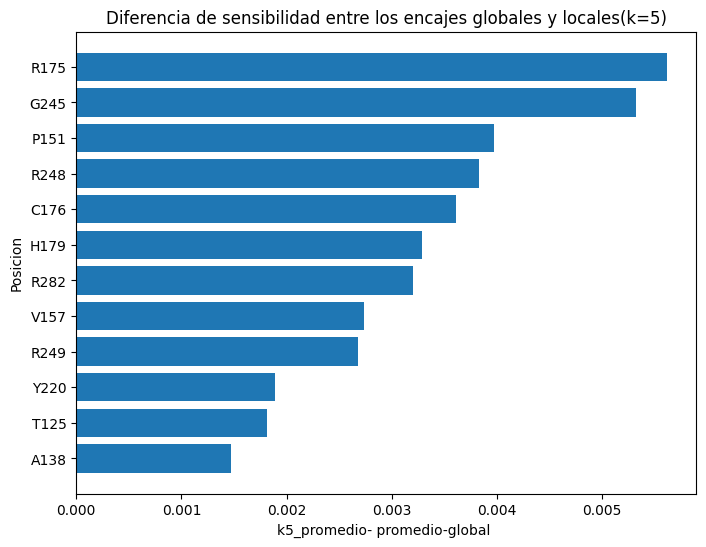

In [ ]:
tmp = compare_rank.sort_values("delta_k5_minus_global", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(tmp["site"], tmp["delta_k5_minus_global"])
plt.xlabel("k5_promedio- promedio-global ")
plt.ylabel("Posicion")
plt.title("Diferencia de sensibilidad entre los encajes globales y locales(k=5)")
plt.savefig("compare_rank.svg")
plt.show()

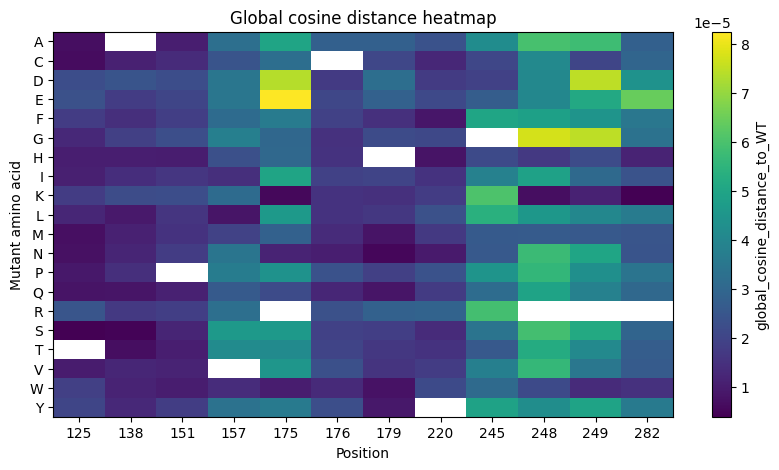

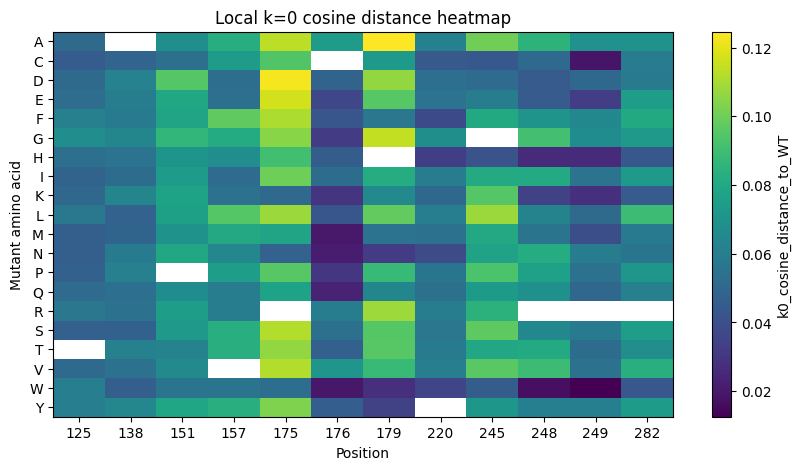

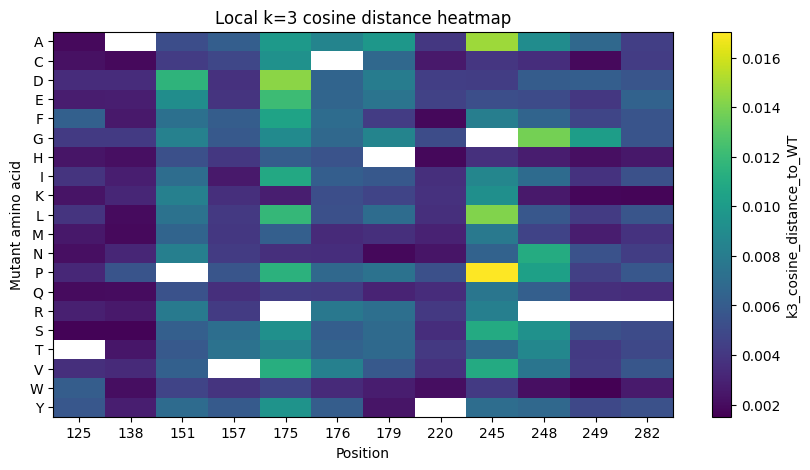

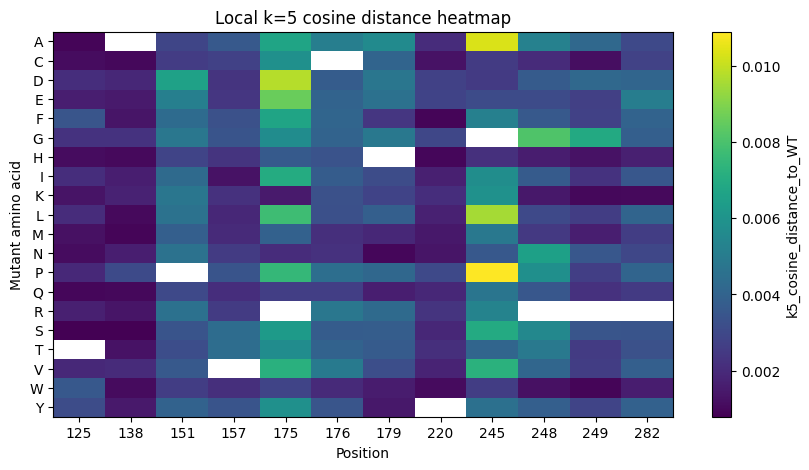

In [ ]:
def plot_heatmap(df, value_col, title):
    heat = df.pivot(index="mut_aa", columns="position", values=value_col)

    plt.figure(figsize=(10, 5))
    plt.imshow(heat.values, aspect="auto")
    plt.xticks(range(len(heat.columns)), heat.columns)
    plt.yticks(range(len(heat.index)), heat.index)
    plt.colorbar(label=value_col)
    plt.xlabel("Position")
    plt.ylabel("Mutant amino acid")
    plt.title(title)
    plt.show()

plot_heatmap(df, "global_cosine_distance_to_WT", "Global cosine distance heatmap")
plot_heatmap(df, "k0_cosine_distance_to_WT", "Local k=0 cosine distance heatmap")
plot_heatmap(df, "k3_cosine_distance_to_WT", "Local k=3 cosine distance heatmap")
plot_heatmap(df, "k5_cosine_distance_to_WT", "Local k=5 cosine distance heatmap")

In [ ]:
df.sort_values("k5_cosine_distance_to_WT", ascending=False)[
    [
        "mutant", "position", "group",
        "global_cosine_distance_to_WT",
        "k0_cosine_distance_to_WT",
        "k3_cosine_distance_to_WT",
        "k5_cosine_distance_to_WT",
    ]
].head(25)

,mutant,position,group,global_cosine_distance_to_WT,k0_cosine_distance_to_WT,k3_cosine_distance_to_WT,k5_cosine_distance_to_WT
49,G245P,245,Hotspots canónicos,0.000045,0.092798,0.017042,0.010893
38,G245A,245,Hotspots canónicos,0.000042,0.100149,0.014754,0.010316
2,R175D,175,Hotspots canónicos,0.000074,0.123258,0.014323,0.009772
46,G245L,245,Hotspots canónicos,0.000054,0.107703,0.014087,0.009524
3,R175E,175,Hotspots canónicos,0.000082,0.117194,0.012150,0.008583
62,R248G,248,Hotspots canónicos,0.000077,0.090978,0.013791,0.008129
9,R175L,175,Hotspots canónicos,0.000046,0.107621,0.011855,0.007739
12,R175P,175,Hotspots canónicos,0.000044,0.095435,0.011504,0.007518
54,G245V,245,Hotspots canónicos,0.000038,0.095909,0.010980,0.007258
16,R175V,175,Hotspots canónicos,0.000045,0.111780,0.011240,0.007193


In [ ]:
df.to_csv("tp53_synthetic_mutants_embedding_metrics.csv", index=False)
summary_by_position.to_csv("tp53_position_summary_embedding_metrics.csv", index=False)

print("Saved:")
print("- tp53_synthetic_mutants_embedding_metrics.csv")
print("- tp53_position_summary_embedding_metrics.csv")

Saved:
- tp53_synthetic_mutants_embedding_metrics.csv
- tp53_position_summary_embedding_metrics.csv


## Revision de cargas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga neta simplificada
aa_charge = {
    "R": "positive", "K": "positive", "H": "positive",
    "D": "negative", "E": "negative",
    "A": "neutral", "C": "neutral", "F": "neutral", "G": "neutral",
    "I": "neutral", "L": "neutral", "M": "neutral", "N": "neutral",
    "P": "neutral", "Q": "neutral", "S": "neutral", "T": "neutral",
    "V": "neutral", "W": "neutral", "Y": "neutral"
}

# Clase fisicoquímica gruesa
aa_class = {
    "A": "hydrophobic", "V": "hydrophobic", "I": "hydrophobic",
    "L": "hydrophobic", "M": "hydrophobic", "F": "hydrophobic",
    "W": "hydrophobic", "Y": "hydrophobic",

    "S": "polar", "T": "polar", "N": "polar", "Q": "polar",
    "C": "polar", "G": "special", "P": "special",

    "D": "charged", "E": "charged", "K": "charged",
    "R": "charged", "H": "charged"
}

# Tamaño aproximado
aa_size = {
    "G": "small", "A": "small", "S": "small", "C": "small",
    "D": "medium", "P": "medium", "N": "medium", "T": "medium",
    "E": "medium", "V": "medium", "Q": "medium", "H": "medium",
    "I": "large", "L": "large", "M": "large", "K": "large",
    "R": "large", "F": "large", "Y": "large", "W": "large"
}

aromatic = {"F", "W", "Y"}
aliphatic = {"A", "V", "I", "L", "M"}
polar = {"S", "T", "N", "Q", "C"}
charged = {"D", "E", "K", "R", "H"}

def annotate_mutation_type(df):
    df = df.copy()

    # Propiedades WT y MUT
    df["wt_charge"] = df["wt_aa"].map(aa_charge)
    df["mut_charge"] = df["mut_aa"].map(aa_charge)

    df["wt_class"] = df["wt_aa"].map(aa_class)
    df["mut_class"] = df["mut_aa"].map(aa_class)

    df["wt_size"] = df["wt_aa"].map(aa_size)
    df["mut_size"] = df["mut_aa"].map(aa_size)

    # Cambios binarios
    df["charge_change"] = df["wt_charge"] != df["mut_charge"]
    df["class_change"] = df["wt_class"] != df["mut_class"]
    df["size_change"] = df["wt_size"] != df["mut_size"]

    # Casos especiales
    df["introduces_proline"] = df["mut_aa"] == "P"
    df["introduces_glycine"] = df["mut_aa"] == "G"
    df["introduces_cysteine"] = df["mut_aa"] == "C"

    df["removes_proline"] = df["wt_aa"] == "P"
    df["removes_glycine"] = df["wt_aa"] == "G"
    df["removes_cysteine"] = df["wt_aa"] == "C"

    # Aromaticidad
    df["wt_aromatic"] = df["wt_aa"].isin(aromatic)
    df["mut_aromatic"] = df["mut_aa"].isin(aromatic)
    df["aromatic_change"] = df["wt_aromatic"] != df["mut_aromatic"]

    # Hidrofobicidad gruesa
    def hydro_group(aa):
        if aa in aliphatic or aa in aromatic:
            return "hydrophobic"
        elif aa in polar:
            return "polar"
        elif aa in charged:
            return "charged"
        elif aa in {"G", "P"}:
            return "special"
        else:
            return "other"

    df["wt_hydro_group"] = df["wt_aa"].map(hydro_group)
    df["mut_hydro_group"] = df["mut_aa"].map(hydro_group)
    df["hydro_group_change"] = df["wt_hydro_group"] != df["mut_hydro_group"]

    # Etiqueta resumida de conservatividad gruesa
    df["is_conservative_like"] = (
        (~df["charge_change"]) &
        (~df["class_change"]) &
        (~df["size_change"])
    )

    return df

df_annot = annotate_mutation_type(df)
df_annot.head()

,mutant,position,wt_aa,mut_aa,group,global_cosine_similarity_to_WT,global_cosine_distance_to_WT,global_euclidean_distance_to_WT,k0_cosine_similarity_to_WT,k0_cosine_distance_to_WT,...,removes_proline,removes_glycine,removes_cysteine,wt_aromatic,mut_aromatic,aromatic_change,wt_hydro_group,mut_hydro_group,hydro_group_change,is_conservative_like
0,R175A,175,R,A,Hotspots canónicos,0.999950,0.000050,0.086051,0.886312,0.113688,...,False,False,False,False,False,False,charged,hydrophobic,True,False
1,R175C,175,R,C,Hotspots canónicos,0.999968,0.000032,0.071122,0.905606,0.094394,...,False,False,False,False,False,False,charged,polar,True,False
2,R175D,175,R,D,Hotspots canónicos,0.999926,0.000074,0.104173,0.876742,0.123258,...,False,False,False,False,False,False,charged,charged,False,False
3,R175E,175,R,E,Hotspots canónicos,0.999918,0.000082,0.110315,0.882806,0.117194,...,False,False,False,False,False,False,charged,charged,False,False
4,R175F,175,R,F,Hotspots canónicos,0.999963,0.000037,0.075071,0.889230,0.110770,...,False,False,False,False,True,True,charged,hydrophobic,True,False


In [ ]:
summary_flags = {
    "charge_change": df_annot["charge_change"].value_counts(),
    "class_change": df_annot["class_change"].value_counts(),
    "size_change": df_annot["size_change"].value_counts(),
    "hydro_group_change": df_annot["hydro_group_change"].value_counts(),
    "introduces_proline": df_annot["introduces_proline"].value_counts(),
    "introduces_glycine": df_annot["introduces_glycine"].value_counts(),
    "introduces_cysteine": df_annot["introduces_cysteine"].value_counts(),
    "aromatic_change": df_annot["aromatic_change"].value_counts(),
    "is_conservative_like": df_annot["is_conservative_like"].value_counts(),
}

for k, v in summary_flags.items():
    print("=" * 60)
    print(k)
    print(v)

charge_change
charge_change
True     120
False    108
Name: count, dtype: int64
class_change
class_change
True     177
False     51
Name: count, dtype: int64
size_change
size_change
True     156
False     72
Name: count, dtype: int64
hydro_group_change
hydro_group_change
True     177
False     51
Name: count, dtype: int64
introduces_proline
introduces_proline
False    217
True      11
Name: count, dtype: int64
introduces_glycine
introduces_glycine
False    217
True      11
Name: count, dtype: int64
introduces_cysteine
introduces_cysteine
False    217
True      11
Name: count, dtype: int64
aromatic_change
aromatic_change
False    178
True      50
Name: count, dtype: int64
is_conservative_like
is_conservative_like
False    216
True      12
Name: count, dtype: int64


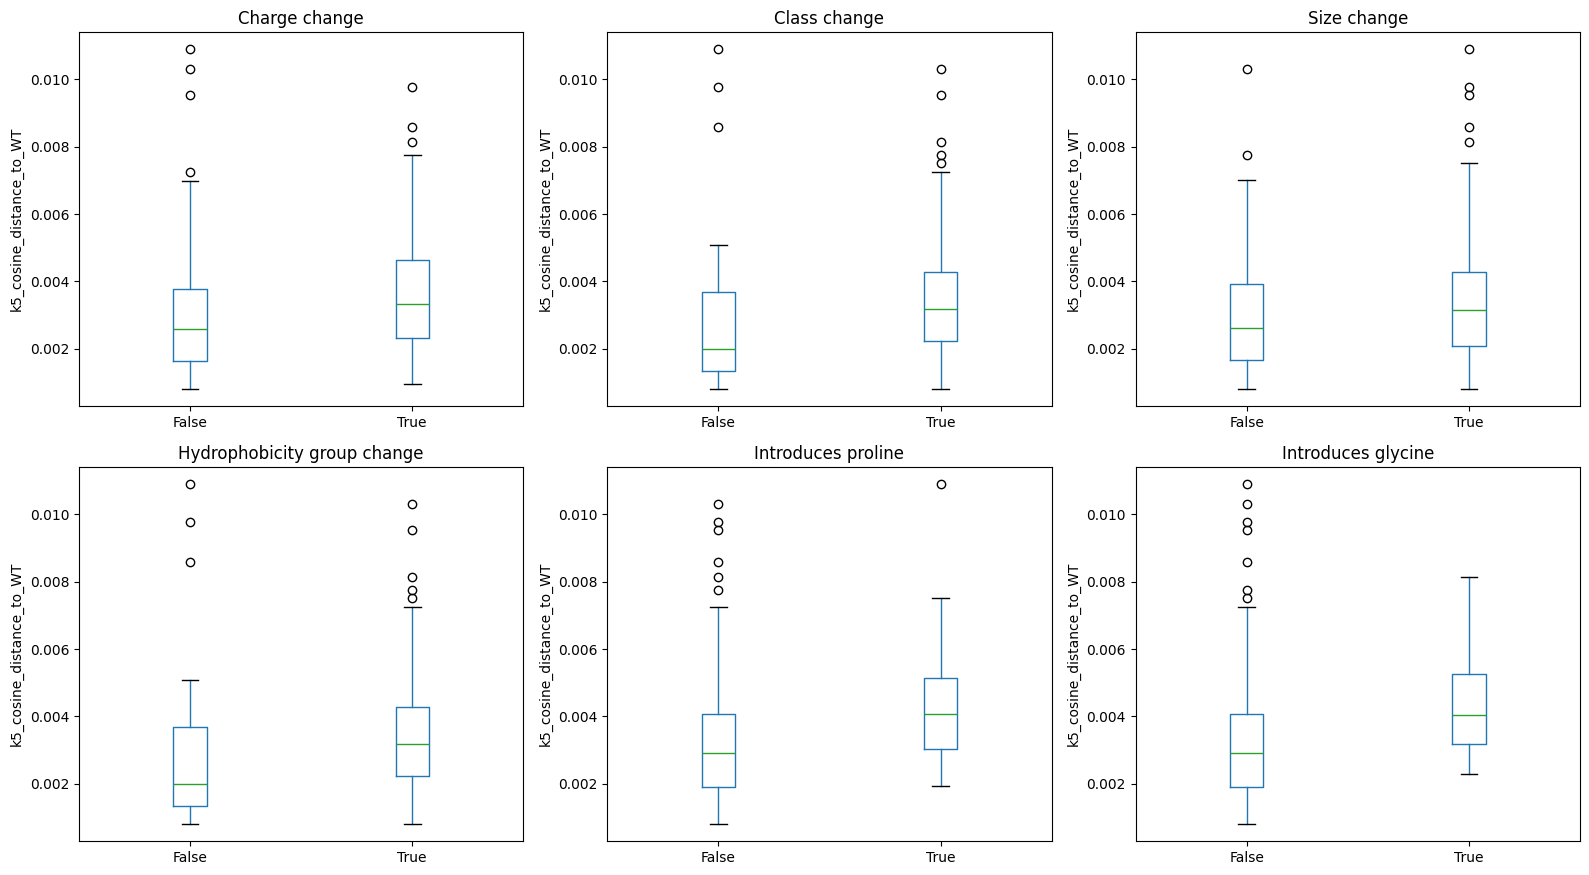

In [ ]:
metric = "k5_cosine_distance_to_WT"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_specs = [
    ("charge_change", "Charge change"),
    ("class_change", "Class change"),
    ("size_change", "Size change"),
    ("hydro_group_change", "Hydrophobicity group change"),
    ("introduces_proline", "Introduces proline"),
    ("introduces_glycine", "Introduces glycine"),
]

for ax, (col, title) in zip(axes.flatten(), plot_specs):
    df_annot.boxplot(column=metric, by=col, grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("")
plt.tight_layout()
plt.savefig("boxplot-categories-vs-k5-cosine-distance.svg")
plt.show()

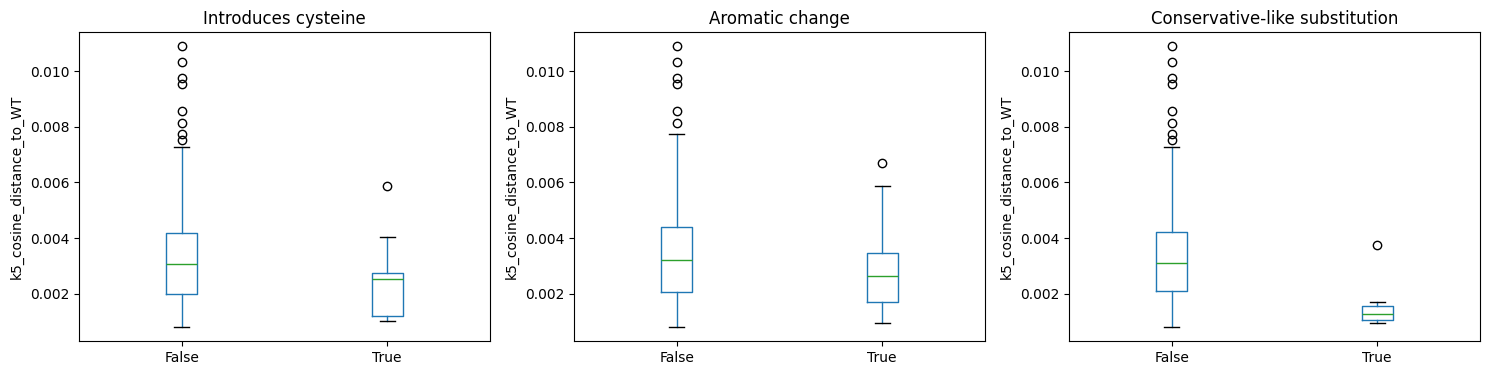

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

extra_specs = [
    ("introduces_cysteine", "Introduces cysteine"),
    ("aromatic_change", "Aromatic change"),
    ("is_conservative_like", "Conservative-like substitution"),
]

for ax, (col, title) in zip(axes.flatten(), extra_specs):
    df_annot.boxplot(column=metric, by=col, grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)

plt.suptitle("")
plt.tight_layout()
plt.savefig("boxplot-categories-vs-k5-cosine-distance2.svg")
plt.show()

In [ ]:
def summarize_by_flag(df, flag_col, metric_col="k5_cosine_distance_to_WT"):
    out = (
        df.groupby(flag_col)[metric_col]
          .agg(["count", "mean", "median", "std", "max"])
          .reset_index()
          .sort_values("mean", ascending=False)
    )
    out["flag"] = flag_col
    return out

summary_tables = []
for col in [
    "charge_change",
    "class_change",
    "size_change",
    "hydro_group_change",
    "introduces_proline",
    "introduces_glycine",
    "introduces_cysteine",
    "aromatic_change",
    "is_conservative_like",
]:
    summary_tables.append(summarize_by_flag(df_annot, col, metric))

summary_flags_df = pd.concat(summary_tables, ignore_index=True)
summary_flags_df

,charge_change,count,mean,median,std,max,flag,class_change,size_change,hydro_group_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
0,True,120,0.003640,0.003336,0.001820,0.009772,charge_change,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,False,108,0.002946,0.002596,0.001859,0.010893,charge_change,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,177,0.003468,0.003166,0.001748,0.010316,class_change,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,51,0.002768,0.001980,0.002164,0.010893,class_change,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,156,0.003426,0.003149,0.001867,0.010893,size_change,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,72,0.003063,0.002626,0.001857,0.010316,size_change,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,177,0.003468,0.003166,0.001748,0.010316,hydro_group_change,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN
7,NaN,51,0.002768,0.001980,0.002164,0.010893,hydro_group_change,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
8,NaN,11,0.004637,0.004060,0.002591,0.010893,introduces_proline,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN
9,NaN,217,0.003244,0.002896,0.001805,0.010316,introduces_proline,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


In [ ]:
cols_to_show = [
    "mutant", "position", "group",
    "wt_aa", "mut_aa",
    "k5_cosine_distance_to_WT",
    "charge_change", "class_change", "size_change",
    "introduces_proline", "introduces_glycine", "introduces_cysteine",
    "aromatic_change", "is_conservative_like"
]

print("Top mutantes que introducen prolina")
display(
    df_annot[df_annot["introduces_proline"]]
    .sort_values("k5_cosine_distance_to_WT", ascending=False)[cols_to_show]
    .head(15)
)

print("Top mutantes que introducen glicina")
display(
    df_annot[df_annot["introduces_glycine"]]
    .sort_values("k5_cosine_distance_to_WT", ascending=False)[cols_to_show]
    .head(15)
)

print("Top mutantes conservativas-like")
display(
    df_annot[df_annot["is_conservative_like"]]
    .sort_values("k5_cosine_distance_to_WT", ascending=False)[cols_to_show]
    .head(15)
)

Top mutantes que introducen prolina


,mutant,position,group,wt_aa,mut_aa,k5_cosine_distance_to_WT,charge_change,class_change,size_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
49,G245P,245,Hotspots canónicos,G,P,0.010893,False,False,True,True,False,False,False,False
12,R175P,175,Hotspots canónicos,R,P,0.007518,True,True,True,True,False,False,False,False
69,R248P,248,Hotspots canónicos,R,P,0.005808,True,True,True,True,False,False,False,False
87,C176P,176,Estructurales,C,P,0.004443,False,True,True,True,False,False,False,False
106,H179P,179,Estructurales,H,P,0.004173,True,True,False,True,False,False,False,False
145,R282P,282,Estructurales,R,P,0.004060,True,True,True,True,False,False,False,False
221,V157P,157,Comparativos del DBD,V,P,0.003431,False,True,False,True,False,False,False,False
182,A138P,138,Comparativos del DBD,A,P,0.003073,False,True,True,True,False,False,False,False
31,Y220P,220,Hotspots canónicos,Y,P,0.003006,False,True,True,True,False,False,True,False
126,R249P,249,Estructurales,R,P,0.002662,True,True,True,True,False,False,False,False


Top mutantes que introducen glicina


,mutant,position,group,wt_aa,mut_aa,k5_cosine_distance_to_WT,charge_change,class_change,size_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
62,R248G,248,Hotspots canónicos,R,G,0.008129,True,True,True,False,True,False,False,False
119,R249G,249,Estructurales,R,G,0.006937,True,True,True,False,True,False,False,False
5,R175G,175,Hotspots canónicos,R,G,0.005703,True,True,True,False,True,False,False,False
100,H179G,179,Estructurales,H,G,0.004834,True,True,True,False,True,False,False,False
195,P151G,151,Comparativos del DBD,P,G,0.004781,False,False,True,False,True,False,False,False
80,C176G,176,Estructurales,C,G,0.004028,False,True,False,False,True,False,False,False
138,R282G,282,Estructurales,R,G,0.003869,True,True,True,False,True,False,False,False
214,V157G,157,Comparativos del DBD,V,G,0.003408,False,True,True,False,True,False,False,False
24,Y220G,220,Hotspots canónicos,Y,G,0.002951,False,True,True,False,True,False,True,False
175,A138G,138,Comparativos del DBD,A,G,0.002288,False,True,False,False,True,False,False,False


Top mutantes conservativas-like


,mutant,position,group,wt_aa,mut_aa,k5_cosine_distance_to_WT,charge_change,class_change,size_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
90,C176S,176,Estructurales,C,S,0.003736,False,False,False,False,False,False,False,True
28,Y220L,220,Hotspots canónicos,Y,L,0.001704,False,False,False,False,False,False,True,True
26,Y220I,220,Hotspots canónicos,Y,I,0.001676,False,False,False,False,False,False,True,True
8,R175K,175,Hotspots canónicos,R,K,0.001540,False,False,False,False,False,False,False,True
29,Y220M,220,Hotspots canónicos,Y,M,0.001445,False,False,False,False,False,False,True,True
65,R248K,248,Hotspots canónicos,R,K,0.001426,False,False,False,False,False,False,False,True
163,T125N,125,Comparativos del DBD,T,N,0.001140,False,False,False,False,False,False,False,True
37,Y220W,220,Hotspots canónicos,Y,W,0.001103,False,False,False,False,False,False,False,True
141,R282K,282,Estructurales,R,K,0.001040,False,False,False,False,False,False,False,True
122,R249K,249,Estructurales,R,K,0.001029,False,False,False,False,False,False,False,True


In [ ]:
df_annot.to_csv("tp53_synthetic_mutants_embedding_metrics_annotated.csv", index=False)
summary_flags_df.to_csv("tp53_mutation_type_summary_k5.csv", index=False)

print("Saved:")
print("- tp53_synthetic_mutants_embedding_metrics_annotated.csv")
print("- tp53_mutation_type_summary_k5.csv")

Saved:
- tp53_synthetic_mutants_embedding_metrics_annotated.csv
- tp53_mutation_type_summary_k5.csv


## Pruebas estadisticas


In [ ]:
!pip -q install scipy statsmodels

In [ ]:
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [ ]:
metric = "k5_cosine_distance_to_WT"

flag_cols = [
    "charge_change",
    "class_change",
    "size_change",
    "hydro_group_change",
    "introduces_proline",
    "introduces_glycine",
    "introduces_cysteine",
    "aromatic_change",
    "is_conservative_like",
]

df_annot[flag_cols + [metric]].head()

,charge_change,class_change,size_change,hydro_group_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like,k5_cosine_distance_to_WT
0,True,True,True,True,False,False,False,False,False,0.006692
1,True,True,True,True,False,False,True,False,False,0.005866
2,True,False,True,False,False,False,False,False,False,0.009772
3,True,False,True,False,False,False,False,False,False,0.008583
4,True,True,False,True,False,False,False,True,False,0.006710


In [ ]:
def mann_whitney_for_flag(df, flag_col, metric_col):
    sub = df[[flag_col, metric_col]].dropna().copy()

    x_false = sub.loc[sub[flag_col] == False, metric_col].values
    x_true  = sub.loc[sub[flag_col] == True,  metric_col].values

    n_false = len(x_false)
    n_true = len(x_true)

    if n_false == 0 or n_true == 0:
        return {
            "flag": flag_col,
            "n_false": n_false,
            "n_true": n_true,
            "mean_false": np.nan,
            "mean_true": np.nan,
            "median_false": np.nan,
            "median_true": np.nan,
            "median_diff_true_minus_false": np.nan,
            "u_stat": np.nan,
            "p_value": np.nan,
            "rank_biserial": np.nan,
        }

    # Mann–Whitney U, dos colas
    u_stat, p_value = mannwhitneyu(x_true, x_false, alternative="two-sided")

    # Rank-biserial correlation
    # RBC = 2U/(n1*n2) - 1, usando U del grupo "true"
    rank_biserial = (2 * u_stat) / (n_true * n_false) - 1

    return {
        "flag": flag_col,
        "n_false": n_false,
        "n_true": n_true,
        "mean_false": float(np.mean(x_false)),
        "mean_true": float(np.mean(x_true)),
        "median_false": float(np.median(x_false)),
        "median_true": float(np.median(x_true)),
        "median_diff_true_minus_false": float(np.median(x_true) - np.median(x_false)),
        "u_stat": float(u_stat),
        "p_value": float(p_value),
        "rank_biserial": float(rank_biserial),
    }

In [ ]:
mw_results = pd.DataFrame(
    [mann_whitney_for_flag(df_annot, col, metric) for col in flag_cols]
)

# Corrección Benjamini–Hochberg
valid_mask = mw_results["p_value"].notna()
rej, p_adj, _, _ = multipletests(
    mw_results.loc[valid_mask, "p_value"].values,
    alpha=0.05,
    method="fdr_bh"
)

mw_results.loc[valid_mask, "p_adj_bh"] = p_adj
mw_results.loc[valid_mask, "significant_bh_0_05"] = rej

mw_results = mw_results.sort_values("p_adj_bh", ascending=True)
mw_results

,flag,n_false,n_true,mean_false,mean_true,median_false,median_true,median_diff_true_minus_false,u_stat,p_value,rank_biserial,p_adj_bh,significant_bh_0_05
8,is_conservative_like,216,12,0.003413,0.001478,0.003111,0.001283,-0.001828,346.0,0.000020,-0.733025,0.000177,True
1,class_change,51,177,0.002768,0.003468,0.001980,0.003166,0.001186,5952.5,0.000529,0.318821,0.001586,True
3,hydro_group_change,51,177,0.002768,0.003468,0.001980,0.003166,0.001186,5952.5,0.000529,0.318821,0.001586,True
0,charge_change,108,120,0.002946,0.003640,0.002596,0.003336,0.000740,8143.0,0.000829,0.256636,0.001865,True
7,aromatic_change,178,50,0.003479,0.002714,0.003193,0.002623,-0.000570,3467.5,0.017181,-0.220787,0.030926,True
5,introduces_glycine,217,11,0.003252,0.004474,0.002896,0.004028,0.001132,1682.0,0.022226,0.409300,0.033340,True
4,introduces_proline,217,11,0.003244,0.004637,0.002896,0.004060,0.001164,1634.0,0.039248,0.369083,0.050462,False
2,size_change,72,156,0.003063,0.003426,0.002626,0.003149,0.000523,6380.0,0.099122,0.136040,0.099122,False
6,introduces_cysteine,217,11,0.003354,0.002466,0.003073,0.002532,-0.000542,831.0,0.089864,-0.303729,0.099122,False


In [ ]:
mw_display = mw_results.copy()

for col in [
    "mean_false", "mean_true",
    "median_false", "median_true",
    "median_diff_true_minus_false",
    "rank_biserial",
    "p_value", "p_adj_bh"
]:
    mw_display[col] = mw_display[col].round(6)

mw_display

,flag,n_false,n_true,mean_false,mean_true,median_false,median_true,median_diff_true_minus_false,u_stat,p_value,rank_biserial,p_adj_bh,significant_bh_0_05
8,is_conservative_like,216,12,0.003413,0.001478,0.003111,0.001283,-0.001828,346.0,0.000020,-0.733025,0.000177,True
1,class_change,51,177,0.002768,0.003468,0.001980,0.003166,0.001186,5952.5,0.000529,0.318821,0.001586,True
3,hydro_group_change,51,177,0.002768,0.003468,0.001980,0.003166,0.001186,5952.5,0.000529,0.318821,0.001586,True
0,charge_change,108,120,0.002946,0.003640,0.002596,0.003336,0.000740,8143.0,0.000829,0.256636,0.001865,True
7,aromatic_change,178,50,0.003479,0.002714,0.003193,0.002623,-0.000570,3467.5,0.017181,-0.220787,0.030926,True
5,introduces_glycine,217,11,0.003252,0.004474,0.002896,0.004028,0.001132,1682.0,0.022226,0.409300,0.033340,True
4,introduces_proline,217,11,0.003244,0.004637,0.002896,0.004060,0.001164,1634.0,0.039248,0.369083,0.050462,False
2,size_change,72,156,0.003063,0.003426,0.002626,0.003149,0.000523,6380.0,0.099122,0.136040,0.099122,False
6,introduces_cysteine,217,11,0.003354,0.002466,0.003073,0.002532,-0.000542,831.0,0.089864,-0.303729,0.099122,False


In [ ]:
def interpret_rbc(rbc):
    a = abs(rbc)
    if a < 0.1:
        return "very small"
    elif a < 0.3:
        return "small"
    elif a < 0.5:
        return "moderate"
    else:
        return "large"

mw_interpret = mw_results.copy()
mw_interpret["effect_size_label"] = mw_interpret["rank_biserial"].apply(
    lambda x: interpret_rbc(x) if pd.notna(x) else np.nan
)

mw_interpret[[
    "flag",
    "median_false",
    "median_true",
    "median_diff_true_minus_false",
    "rank_biserial",
    "effect_size_label",
    "p_value",
    "p_adj_bh",
    "significant_bh_0_05",
]].sort_values("p_adj_bh")

,flag,median_false,median_true,median_diff_true_minus_false,rank_biserial,effect_size_label,p_value,p_adj_bh,significant_bh_0_05
8,is_conservative_like,0.003111,0.001283,-0.001828,-0.733025,large,0.000020,0.000177,True
1,class_change,0.001980,0.003166,0.001186,0.318821,moderate,0.000529,0.001586,True
3,hydro_group_change,0.001980,0.003166,0.001186,0.318821,moderate,0.000529,0.001586,True
0,charge_change,0.002596,0.003336,0.000740,0.256636,small,0.000829,0.001865,True
7,aromatic_change,0.003193,0.002623,-0.000570,-0.220787,small,0.017181,0.030926,True
5,introduces_glycine,0.002896,0.004028,0.001132,0.409300,moderate,0.022226,0.033340,True
4,introduces_proline,0.002896,0.004060,0.001164,0.369083,moderate,0.039248,0.050462,False
2,size_change,0.002626,0.003149,0.000523,0.136040,small,0.099122,0.099122,False
6,introduces_cysteine,0.003073,0.002532,-0.000542,-0.303729,moderate,0.089864,0.099122,False


In [ ]:

mw_interpret.to_csv("mannwhitney_k5_results.csv", index=False, encoding='utf-8')
print("Saved: mannwhitney_k5_results.csv")

Saved: mannwhitney_k5_results.csv


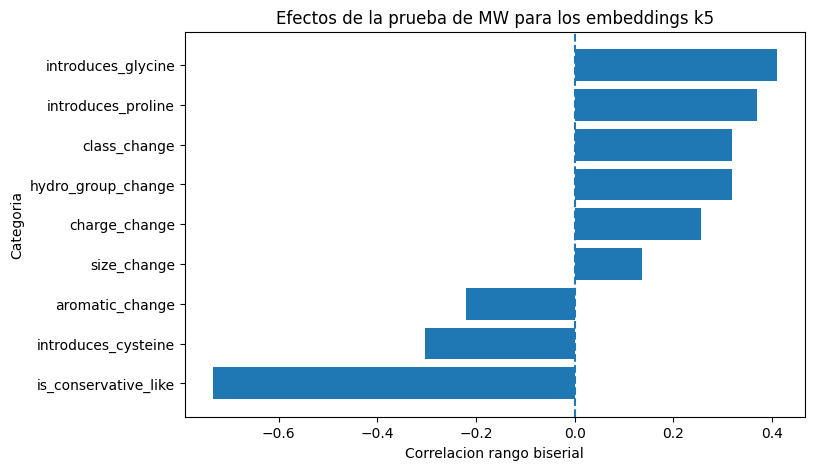

In [ ]:
import matplotlib.pyplot as plt

tmp = mw_results.sort_values("rank_biserial", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(tmp["flag"], tmp["rank_biserial"])
plt.axvline(0, linestyle="--")
plt.xlabel("Correlacion rango biserial")
plt.ylabel("Categoria")
plt.title(f"Efectos de la prueba de MW para los embeddings k5")
plt.savefig("mannwhitney-effect-sizes-k5-cosine.svg")
plt.show()

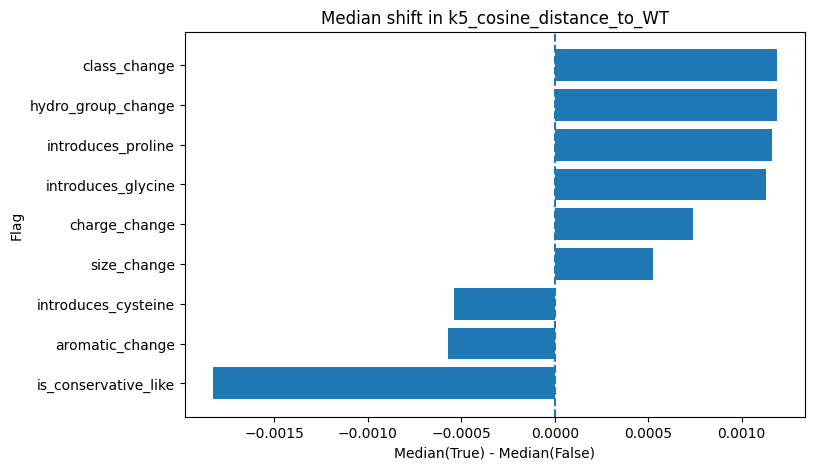

In [ ]:
tmp = mw_results.copy()
tmp["median_true_minus_false"] = tmp["median_true"] - tmp["median_false"]
tmp = tmp.sort_values("median_true_minus_false", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(tmp["flag"], tmp["median_true_minus_false"])
plt.axvline(0, linestyle="--")
plt.xlabel("Median(True) - Median(False)")
plt.ylabel("Flag")
plt.title(f"Median shift in {metric}")
plt.savefig("median-shift-k5-cosine.svg")
plt.show()

In [ ]:
mw_results.to_csv("tp53_mannwhitney_k5_results.csv", index=False)
print("Saved: tp53_mannwhitney_k5_results.csv")

Saved: tp53_mannwhitney_k5_results.csv


#FASE 2


In [ ]:
!pip -q install requests scipy statsmodels

In [ ]:
import io
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr, mannwhitneyu

In [ ]:
# Score set recomendado para empezar
MAVEDB_URN = "urn:mavedb:00000068-0-1"

base = "https://api.mavedb.org/api/v1"
url_scores = f"{base}/score-sets/{MAVEDB_URN}/scores"
url_meta = f"{base}/score-sets/{MAVEDB_URN}"

meta = requests.get(url_meta, timeout=60)
meta.raise_for_status()
meta_json = meta.json()

scores = requests.get(url_scores, timeout=60)
scores.raise_for_status()

mave_raw = pd.read_csv(io.StringIO(scores.text))

print("Title:", meta_json.get("title", "N/A"))
print("URN:", MAVEDB_URN)
print("Shape:", mave_raw.shape)
print("\nColumns:")
print(list(mave_raw.columns))
display(mave_raw.head())

Title: Combined score using three assays of TP53 activity that assess loss of function or dominant negative effect
URN: urn:mavedb:00000068-0-1
Shape: (8258, 5)

Columns:
['accession', 'hgvs_nt', 'hgvs_splice', 'hgvs_pro', 'score']


,accession,hgvs_nt,hgvs_splice,hgvs_pro,score
0,urn:mavedb:00000068-0-1#1,NaN,NaN,p.Met1Ala,-0.450940
1,urn:mavedb:00000068-0-1#2,NaN,NaN,p.Met1Cys,-0.193730
2,urn:mavedb:00000068-0-1#3,NaN,NaN,p.Met1Asp,-0.340391
3,urn:mavedb:00000068-0-1#4,NaN,NaN,p.Met1Glu,-1.176049
4,urn:mavedb:00000068-0-1#5,NaN,NaN,p.Met1Phe,-0.340391


In [ ]:
def pick_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

variant_candidates = [
    "hgvs_pro", "hgvs_p", "protein_variant", "variant",
    "aa_variant", "amino_acid_change", "protein_change"
]

score_candidates = [
    "score", "main_score", "functional_score",
    "score_value", "normalized_score"
]

variant_col = pick_first_existing(mave_raw.columns, variant_candidates)
score_col = pick_first_existing(mave_raw.columns, score_candidates)

print("Auto-detected variant_col:", variant_col)
print("Auto-detected score_col:", score_col)

if variant_col is None:
    print("\nNo pude detectar automáticamente la columna de variante.")
    print("Columnas disponibles:")
    print(list(mave_raw.columns))

if score_col is None:
    print("\nNo pude detectar automáticamente la columna de score.")
    numeric_cols = [c for c in mave_raw.columns if pd.api.types.is_numeric_dtype(mave_raw[c])]
    print("Columnas numéricas candidatas:")
    print(numeric_cols)

Auto-detected variant_col: hgvs_pro
Auto-detected score_col: score


In [ ]:
aa3_to_aa1 = {
    "Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C",
    "Gln": "Q", "Glu": "E", "Gly": "G", "His": "H", "Ile": "I",
    "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P",
    "Ser": "S", "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V",
    "Ter": "*", "Stop": "*"
}

def normalize_protein_variant(x):
    if pd.isna(x):
        return None

    s = str(x).strip()

    # quitar prefijo p.
    s = re.sub(r"^p\.", "", s)

    # Caso 1: una letra, p. R175H
    m1 = re.match(r"^([A-Z\*])(\d+)([A-Z\*])$", s)
    if m1:
        wt, pos, mut = m1.groups()
        return f"{wt}{pos}{mut}"

    # Caso 2: tres letras, p.Arg175His
    m2 = re.match(r"^([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|Ter|Stop)$", s)
    if m2:
        wt3, pos, mut3 = m2.groups()
        wt = aa3_to_aa1.get(wt3)
        mut = aa3_to_aa1.get(mut3)
        if wt is not None and mut is not None:
            return f"{wt}{pos}{mut}"

    return None

mave = mave_raw.copy()
mave["mutant"] = mave[variant_col].apply(normalize_protein_variant)
mave["score_raw"] = pd.to_numeric(mave[score_col], errors="coerce")

display(mave[[variant_col, "mutant", score_col, "score_raw"]].head(20))
print("Mutantes parseados:", mave["mutant"].notna().sum())

,hgvs_pro,mutant,score,score_raw
0,p.Met1Ala,M1A,-0.450940,-0.450940
1,p.Met1Cys,M1C,-0.193730,-0.193730
2,p.Met1Asp,M1D,-0.340391,-0.340391
3,p.Met1Glu,M1E,-1.176049,-1.176049
4,p.Met1Phe,M1F,-0.340391,-0.340391
5,p.Met1Gly,M1G,0.196891,0.196891
6,p.Met1His,M1H,0.074199,0.074199
7,p.Met1Ile,M1I,0.049097,0.049097
8,p.Met1Lys,M1K,-0.091925,-0.091925
9,p.Met1Leu,M1L,0.202724,0.202724


Mutantes parseados: 7880


In [ ]:
missense_pattern = re.compile(r"^[ACDEFGHIKLMNPQRSTVWY](\d+)[ACDEFGHIKLMNPQRSTVWY]$")

mave_missense = mave[
    mave["mutant"].notna() &
    mave["mutant"].str.match(missense_pattern) &
    mave["score_raw"].notna()
].copy()

# Si hay duplicados por mutante, promediamos
mave_missense = (
    mave_missense.groupby("mutant", as_index=False)
    .agg(score_raw=("score_raw", "mean"))
)

print("MAVE missense shape:", mave_missense.shape)
display(mave_missense.head())

MAVE missense shape: (7467, 2)


,mutant,score_raw
0,A119C,0.119537
1,A119D,-0.354409
2,A119E,-0.112447
3,A119F,-0.349445
4,A119G,-0.577829


In [ ]:
merge_cols = [
    "mutant", "position", "wt_aa", "mut_aa", "group",
    "global_cosine_distance_to_WT",
    "k0_cosine_distance_to_WT",
    "k3_cosine_distance_to_WT",
    "k5_cosine_distance_to_WT",
    "class_change", "hydro_group_change", "is_conservative_like",
    "introduces_glycine", "introduces_proline", "introduces_cysteine"
]

tp53_panel_real = df_annot[merge_cols].merge(
    mave_missense,
    on="mutant",
    how="inner"
)

print("Overlap con panel:", tp53_panel_real.shape)
display(tp53_panel_real.head())
print("\nNúmero de posiciones con datos reales:")
print(tp53_panel_real["position"].value_counts().sort_index())

Overlap con panel: (228, 16)


,mutant,position,wt_aa,mut_aa,group,global_cosine_distance_to_WT,k0_cosine_distance_to_WT,k3_cosine_distance_to_WT,k5_cosine_distance_to_WT,class_change,hydro_group_change,is_conservative_like,introduces_glycine,introduces_proline,introduces_cysteine,score_raw
0,R175A,175,R,A,Hotspots canónicos,0.000050,0.113688,0.009833,0.006692,True,True,False,False,False,False,0.747043
1,R175C,175,R,C,Hotspots canónicos,0.000032,0.094394,0.009359,0.005866,True,True,False,False,False,True,-0.547151
2,R175D,175,R,D,Hotspots canónicos,0.000074,0.123258,0.014323,0.009772,False,False,False,False,False,False,1.481232
3,R175E,175,R,E,Hotspots canónicos,0.000082,0.117194,0.012150,0.008583,False,False,False,False,False,False,1.711013
4,R175F,175,R,F,Hotspots canónicos,0.000037,0.110770,0.010538,0.006710,True,True,False,False,False,False,1.578232



Número de posiciones con datos reales:
position
125    19
138    19
151    19
157    19
175    19
176    19
179    19
220    19
245    19
248    19
249    19
282    19
Name: count, dtype: int64


In [ ]:
canonical_bad = ["R175H", "G245S", "R248Q", "R248W", "R273H", "R282W"]

check = tp53_panel_real[tp53_panel_real["mutant"].isin(canonical_bad)].copy()
display(check[["mutant", "score_raw", "k5_cosine_distance_to_WT"]].sort_values("mutant"))

print(
    "Interpreta esta tabla así:\n"
    "- si estos mutantes dañinos salen con scores bajos, entonces score_raw probablemente ya significa 'más funcional = mayor'.\n"
    "- si salen con scores altos, convendrá invertir el signo."
)

,mutant,score_raw,k5_cosine_distance_to_WT
52,G245S,0.771774,0.006983
6,R175H,1.024850,0.003658
70,R248Q,0.811973,0.003552
74,R248W,0.951960,0.001252
150,R282W,1.025667,0.001606


Interpreta esta tabla así:
- si estos mutantes dañinos salen con scores bajos, entonces score_raw probablemente ya significa 'más funcional = mayor'.
- si salen con scores altos, convendrá invertir el signo.


In [ ]:
flip_score = False  # cambia a True si ves que el score está invertido

tp53_panel_real = tp53_panel_real.copy()
tp53_panel_real["functional_score"] = (
    -tp53_panel_real["score_raw"] if flip_score else tp53_panel_real["score_raw"]
)

display(
    tp53_panel_real[["mutant", "score_raw", "functional_score"]].head()
)

,mutant,score_raw,functional_score
0,R175A,0.747043,0.747043
1,R175C,-0.547151,-0.547151
2,R175D,1.481232,1.481232
3,R175E,1.711013,1.711013
4,R175F,1.578232,1.578232


In [ ]:
def corr_report(x, y, label_x):
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    sp = spearmanr(x, y)
    pr = pearsonr(x, y)

    return {
        "metric": label_x,
        "n": len(x),
        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
        "pearson_r": pr.statistic,
        "pearson_p": pr.pvalue,
    }

corr_table = pd.DataFrame([
    corr_report(tp53_panel_real["global_cosine_distance_to_WT"], tp53_panel_real["functional_score"], "global"),
    corr_report(tp53_panel_real["k3_cosine_distance_to_WT"], tp53_panel_real["functional_score"], "k3"),
    corr_report(tp53_panel_real["k5_cosine_distance_to_WT"], tp53_panel_real["functional_score"], "k5"),
])

corr_table



,metric,n,spearman_rho,spearman_p,pearson_r,pearson_p
0,global,228,0.234914,3.464668e-04,0.223530,0.000674
1,k3,228,0.324792,5.333844e-07,0.257730,0.000083
2,k5,228,0.312365,1.497098e-06,0.229735,0.000471


In [ ]:
corr_table.to_csv("correlation-embedding-table.csv")

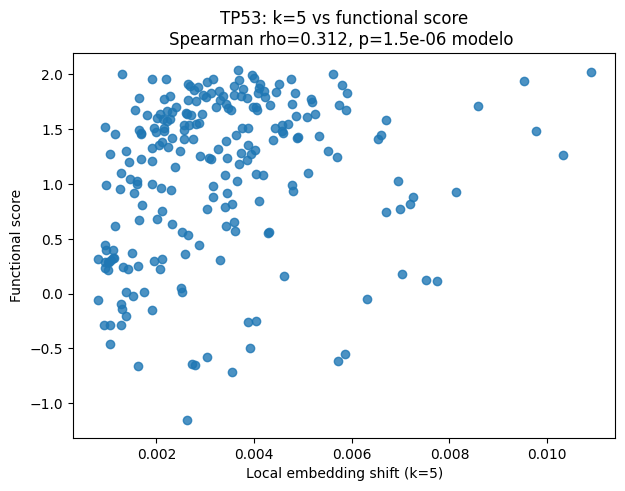

In [ ]:
x = tp53_panel_real["k5_cosine_distance_to_WT"].values
y = tp53_panel_real["functional_score"].values

rho, pval = spearmanr(x, y)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("Local embedding shift (k=5)")
plt.ylabel("Functional score")
plt.title(f"TP53: k=5 vs functional score\nSpearman rho={rho:.3f}, p={pval:.3g} modelo ")
plt.savefig("embedding-vs-functional-score-k5.svg")
plt.show()

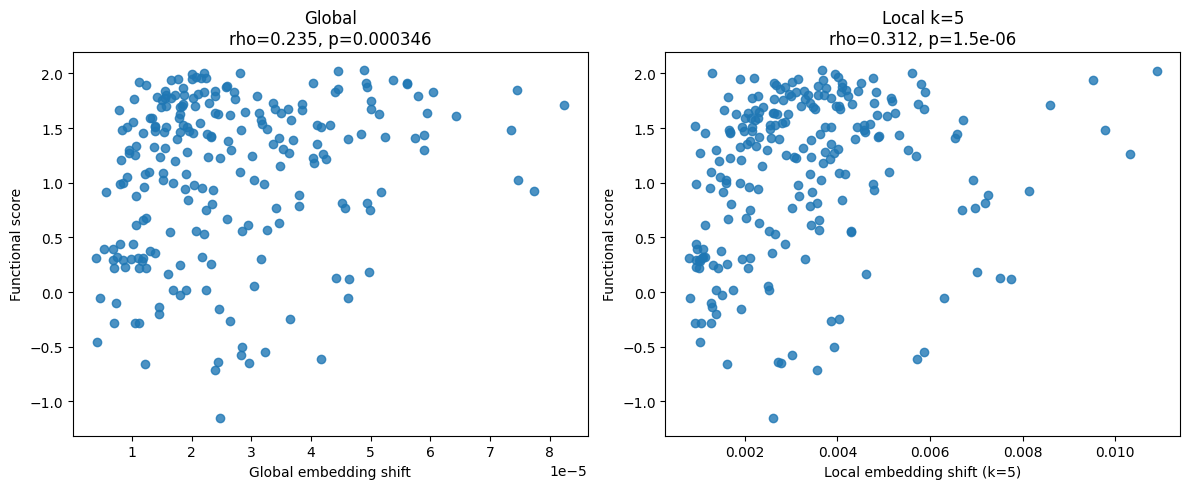

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = tp53_panel_real["global_cosine_distance_to_WT"].values
y = tp53_panel_real["functional_score"].values
rho, pval = spearmanr(x, y)
axes[0].scatter(x, y, alpha=0.8)
axes[0].set_xlabel("Global embedding shift")
axes[0].set_ylabel("Functional score")
axes[0].set_title(f"Global\nrho={rho:.3f}, p={pval:.3g}")

x = tp53_panel_real["k5_cosine_distance_to_WT"].values
y = tp53_panel_real["functional_score"].values
rho, pval = spearmanr(x, y)
axes[1].scatter(x, y, alpha=0.8)
axes[1].set_xlabel("Local embedding shift (k=5)")
axes[1].set_ylabel("Functional score")
axes[1].set_title(f"Local k=5\nrho={rho:.3f}, p={pval:.3g}")

plt.tight_layout()
plt.savefig("embedding-vs-functional-score-global-k5.svg")
plt.show()

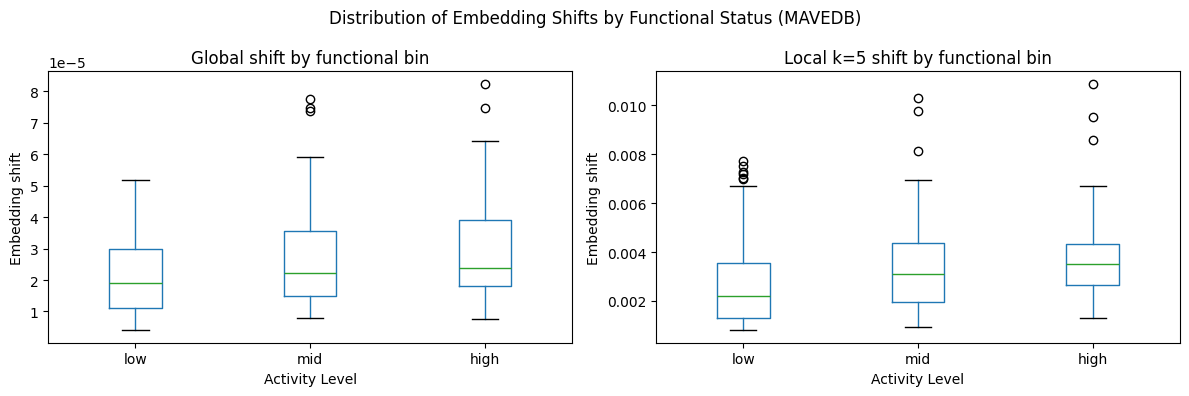

In [ ]:
# Actualizamos las etiquetas antes de graficar el histograma/boxplot por terciles funcionales
tp53_panel_real = tp53_panel_real.copy()

# Aseguramos que los nombres de los grupos en el dataframe coincidan con los nuevos nombres
group_rename_map = {
    "hotspot": "DNA Binding Hotspots",
    "structural": "Structural Stability Sites",
    "comparison_dbd": "Other DBD Surface Sites"
}
tp53_panel_real["group"] = tp53_panel_real["group"].replace(group_rename_map)

# Creación de terciles funcionales (Low, Mid, High activity)
tp53_panel_real["functional_bin"] = pd.qcut(
    tp53_panel_real["functional_score"],
    q=3,
    labels=["low", "mid", "high"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tp53_panel_real.boxplot(column="global_cosine_distance_to_WT", by="functional_bin", grid=False, ax=axes[0])
axes[0].set_title("Global shift by functional bin")
axes[0].set_xlabel("Activity Level")
axes[0].set_ylabel("Embedding shift")

tp53_panel_real.boxplot(column="k5_cosine_distance_to_WT", by="functional_bin", grid=False, ax=axes[1])
axes[1].set_title("Local k=5 shift by functional bin")
axes[1].set_xlabel("Activity Level")
axes[1].set_ylabel("Embedding shift")

plt.suptitle("Distribution of Embedding Shifts by Functional Status (MAVEDB)")
plt.tight_layout()
plt.savefig("histogram-embeding-shift.svg")
plt.show()

In [ ]:
low = tp53_panel_real.loc[tp53_panel_real["functional_bin"] == "low", "k5_cosine_distance_to_WT"].values
high = tp53_panel_real.loc[tp53_panel_real["functional_bin"] == "high", "k5_cosine_distance_to_WT"].values

u, p = mannwhitneyu(low, high, alternative="two-sided")

print("Mann–Whitney low vs high on k5")
print("n_low =", len(low))
print("n_high =", len(high))
print("U =", u)
print("p =", p)
print("median_low =", np.median(low))
print("median_high =", np.median(high))

Mann–Whitney low vs high on k5
n_low = 76
n_high = 76
U = 1725.0
p = 1.837680947876241e-05
median_low = 0.002207934856414795
median_high = 0.00349387526512146


In [ ]:
tp53_panel_real["abs_k5"] = tp53_panel_real["k5_cosine_distance_to_WT"].abs()
tp53_panel_real["abs_score"] = tp53_panel_real["functional_score"].abs()

display(
    tp53_panel_real.sort_values("k5_cosine_distance_to_WT", ascending=False)[
        ["mutant", "position", "group", "k5_cosine_distance_to_WT", "functional_score"]
    ].head(20)
)

display(
    tp53_panel_real.sort_values("functional_score", ascending=True)[
        ["mutant", "position", "group", "k5_cosine_distance_to_WT", "functional_score"]
    ].head(20)
)

,mutant,position,group,k5_cosine_distance_to_WT,functional_score
49,G245P,245,Hotspots canónicos,0.010893,2.020795
38,G245A,245,Hotspots canónicos,0.010316,1.261439
2,R175D,175,Hotspots canónicos,0.009772,1.481232
46,G245L,245,Hotspots canónicos,0.009524,1.937388
3,R175E,175,Hotspots canónicos,0.008583,1.711013
62,R248G,248,Hotspots canónicos,0.008129,0.924123
9,R175L,175,Hotspots canónicos,0.007739,0.118287
12,R175P,175,Hotspots canónicos,0.007518,0.124805
54,G245V,245,Hotspots canónicos,0.007258,0.883436
16,R175V,175,Hotspots canónicos,0.007193,0.813730


,mutant,position,group,k5_cosine_distance_to_WT,functional_score
143,R282M,282,Estructurales,0.002615,-1.155030
140,R282I,282,Estructurales,0.003551,-0.714421
181,A138N,138,Comparativos del DBD,0.001628,-0.659453
134,R282C,282,Estructurales,0.002793,-0.650297
210,V157C,157,Comparativos del DBD,0.002728,-0.642573
15,R175T,175,Hotspots canónicos,0.005719,-0.614061
133,R282A,282,Estructurales,0.003031,-0.578041
1,R175C,175,Hotspots canónicos,0.005866,-0.547151
10,R175M,175,Hotspots canónicos,0.003921,-0.501134
141,R282K,282,Estructurales,0.001040,-0.460369


In [ ]:
corr_table.to_csv("tp53_panel_functional_correlations.csv", index=False)
tp53_panel_real.to_csv("tp53_panel_with_functional_scores.csv", index=False)

print("Saved:")
print("- tp53_panel_functional_correlations.csv")
print("- tp53_panel_with_functional_scores.csv")

Saved:
- tp53_panel_functional_correlations.csv
- tp53_panel_with_functional_scores.csv


In [ ]:
## Correlaciones

from scipy.stats import spearmanr, pearsonr, kendalltau
import pandas as pd
import numpy as np

In [ ]:
def correlation_report(df, x_col, y_col, label=None):
    sub = df[[x_col, y_col]].dropna().copy()

    x = sub[x_col].values
    y = sub[y_col].values

    sp = spearmanr(x, y)
    pr = pearsonr(x, y)
    kt = kendalltau(x, y)

    return {
        "label": label if label is not None else x_col,
        "n": len(sub),
        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
        "pearson_r": pr.statistic,
        "pearson_p": pr.pvalue,
        "kendall_tau": kt.statistic,
        "kendall_p": kt.pvalue,
    }

In [ ]:
score_col = "score_raw"   # o "combined_lof_dn_score" / "activity_score"

corr_table = pd.DataFrame([
    correlation_report(tp53_panel_real, "global_cosine_distance_to_WT", score_col, "global"),
    correlation_report(tp53_panel_real, "k3_cosine_distance_to_WT", score_col, "local_k3"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", score_col, "local_k5"),
])

corr_table

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,global,228,0.234914,3.464668e-04,0.223530,0.000674,0.160528,3.115564e-04
1,local_k3,228,0.324792,5.333844e-07,0.257730,0.000083,0.225983,3.786197e-07
2,local_k5,228,0.312365,1.497098e-06,0.229735,0.000471,0.217138,1.058153e-06


In [ ]:
corr_table_round = corr_table.copy()

for col in corr_table_round.columns:
    if col not in ["label", "n"]:
        corr_table_round[col] = corr_table_round[col].round(6)

corr_table_round

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,global,228,0.234914,0.000346,0.223530,0.000674,0.160528,0.000312
1,local_k3,228,0.324792,0.000001,0.257730,0.000083,0.225983,0.000000
2,local_k5,228,0.312365,0.000001,0.229735,0.000471,0.217138,0.000001


In [ ]:
## BLOSUM

In [ ]:
from Bio.Align import substitution_matrices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, kendalltau

blosum62 = substitution_matrices.load("BLOSUM62")


In [ ]:
def get_blosum_score(wt, mut, matrix):
    try:
        return -float(matrix[(wt, mut)])
    except Exception:
        try:
            return -float(matrix[(mut, wt)])
        except Exception:
            return np.nan

In [ ]:
tp53_panel_real = tp53_panel_real.copy()

tp53_panel_real["blosum62_score"] = [
    get_blosum_score(w, m, blosum62)
    for w, m in zip(tp53_panel_real["wt_aa"], tp53_panel_real["mut_aa"])
]

tp53_panel_real[["mutant", "wt_aa", "mut_aa", "blosum62_score"]].head(20)

,mutant,wt_aa,mut_aa,blosum62_score
0,R175A,R,A,1.0
1,R175C,R,C,3.0
2,R175D,R,D,2.0
3,R175E,R,E,-0.0
4,R175F,R,F,3.0
5,R175G,R,G,2.0
6,R175H,R,H,-0.0
7,R175I,R,I,3.0
8,R175K,R,K,-2.0
9,R175L,R,L,2.0


In [ ]:
tp53_panel_real["combined_lof_dn_score"] = tp53_panel_real["score_raw"]
tp53_panel_real["activity_score"] = -tp53_panel_real["score_raw"]

tp53_panel_real[["mutant", "combined_lof_dn_score", "activity_score"]].head()

,mutant,combined_lof_dn_score,activity_score
0,R175A,0.747043,-0.747043
1,R175C,-0.547151,0.547151
2,R175D,1.481232,-1.481232
3,R175E,1.711013,-1.711013
4,R175F,1.578232,-1.578232


In [ ]:
def correlation_report(df, x_col, y_col, label=None):
    sub = df[[x_col, y_col]].dropna().copy()

    x = sub[x_col].values
    y = sub[y_col].values

    sp = spearmanr(x, y)
    pr = pearsonr(x, y)
    kt = kendalltau(x, y)

    return {
        "label": label if label is not None else x_col,
        "n": len(sub),
        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
        "pearson_r": pr.statistic,
        "pearson_p": pr.pvalue,
        "kendall_tau": kt.statistic,
        "kendall_p": kt.pvalue,
    }

In [ ]:
corr_compare_deleterious = pd.DataFrame([
    correlation_report(tp53_panel_real, "blosum62_score", "combined_lof_dn_score", "BLOSUM62 vs deleteriousness"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", "combined_lof_dn_score", "ESM local k=5 vs deleteriousness"),
])

corr_compare_deleterious

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,BLOSUM62 vs deleteriousness,228,0.298836,0.000004,0.286127,0.000011,0.222308,0.000005
1,ESM local k=5 vs deleteriousness,228,0.312365,0.000001,0.229735,0.000471,0.217138,0.000001


In [ ]:
corr_compare_activity = pd.DataFrame([
    correlation_report(tp53_panel_real, "blosum62_score", "activity_score", "BLOSUM62 vs activity"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", "activity_score", "ESM local k=5 vs activity"),
])

corr_compare_activity

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,BLOSUM62 vs activity,228,-0.298836,0.000004,-0.286127,0.000011,-0.222308,0.000005
1,ESM local k=5 vs activity,228,-0.312365,0.000001,-0.229735,0.000471,-0.217138,0.000001


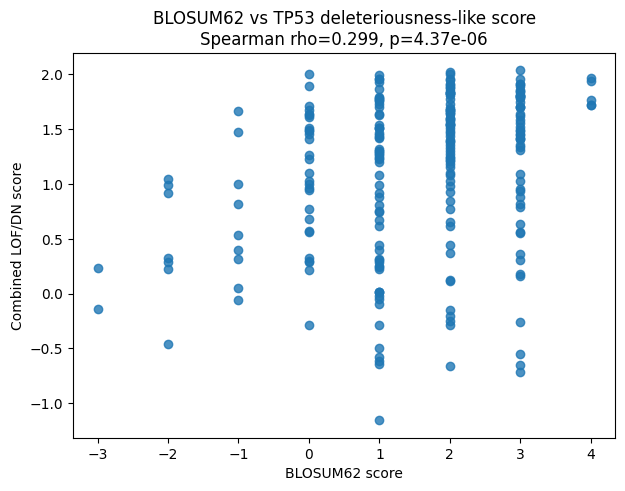

In [ ]:
x = tp53_panel_real["blosum62_score"].values
y = tp53_panel_real["combined_lof_dn_score"].values

rho, pval = spearmanr(x, y)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("BLOSUM62 score")
plt.ylabel("Combined LOF/DN score")
plt.title(f"BLOSUM62 vs TP53 deleteriousness-like score\nSpearman rho={rho:.3f}, p={pval:.3g}")
plt.show()

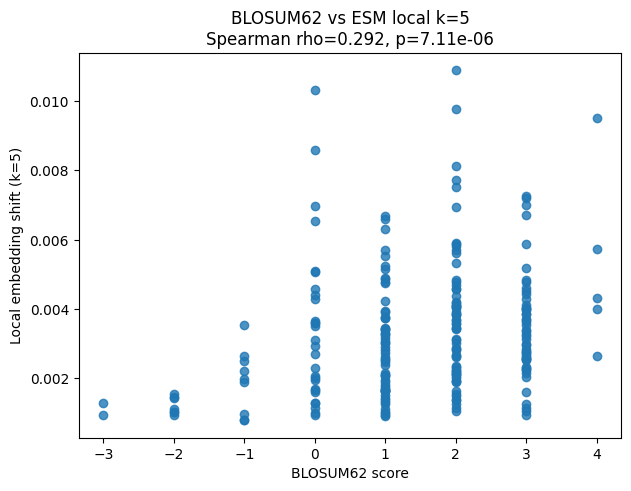

In [ ]:
x = tp53_panel_real["blosum62_score"].values
y = tp53_panel_real["k5_cosine_distance_to_WT"].values

rho, pval = spearmanr(x, y)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("BLOSUM62 score")
plt.ylabel("Local embedding shift (k=5)")
plt.title(f"BLOSUM62 vs ESM local k=5\nSpearman rho={rho:.3f}, p={pval:.3g}")
plt.show()

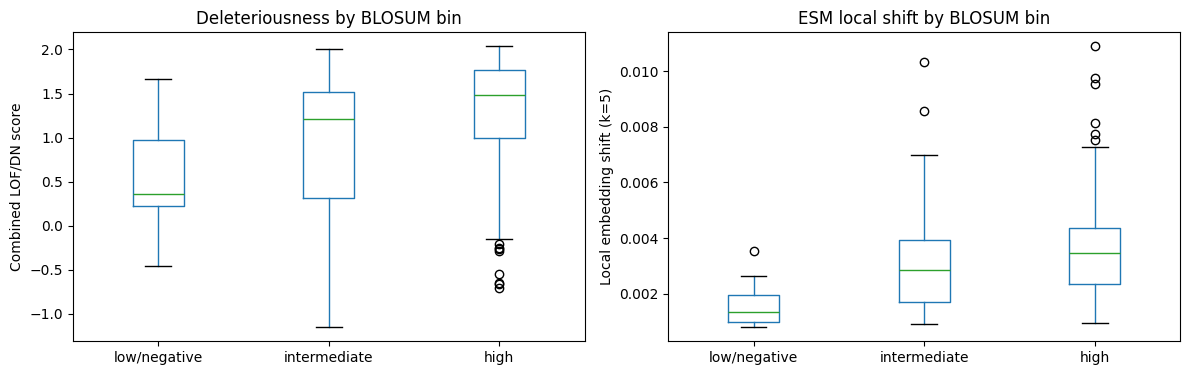

In [ ]:
tp53_panel_real["blosum_bin"] = pd.cut(
    tp53_panel_real["blosum62_score"],
    bins=[-10, -1, 1, 20],
    labels=["low/negative", "intermediate", "high"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tp53_panel_real.boxplot(column="combined_lof_dn_score", by="blosum_bin", grid=False, ax=axes[0])
axes[0].set_title("Deleteriousness by BLOSUM bin")
axes[0].set_xlabel("")
axes[0].set_ylabel("Combined LOF/DN score")

tp53_panel_real.boxplot(column="k5_cosine_distance_to_WT", by="blosum_bin", grid=False, ax=axes[1])
axes[1].set_title("ESM local shift by BLOSUM bin")
axes[1].set_xlabel("")
axes[1].set_ylabel("Local embedding shift (k=5)")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
benchmark_table = pd.DataFrame([
    correlation_report(tp53_panel_real, "blosum62_score", "combined_lof_dn_score", "BLOSUM62"),
    correlation_report(tp53_panel_real, "global_cosine_distance_to_WT", "combined_lof_dn_score", "ESM global"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", "combined_lof_dn_score", "ESM local k=5"),
])

benchmark_table

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,BLOSUM62,228,0.298836,0.000004,0.286127,0.000011,0.222308,0.000005
1,ESM global,228,0.234914,0.000346,0.223530,0.000674,0.160528,0.000312
2,ESM local k=5,228,0.312365,0.000001,0.229735,0.000471,0.217138,0.000001


In [ ]:
tp53_panel_real.to_csv("tp53_panel_with_blosum.csv", index=False)
benchmark_table.to_csv("tp53_benchmark_blosum_vs_esm.csv", index=False)

print("Saved:")
print("- tp53_panel_with_blosum.csv")
print("- tp53_benchmark_blosum_vs_esm.csv")

Saved:
- tp53_panel_with_blosum.csv
- tp53_benchmark_blosum_vs_esm.csv


In [ ]:
## Comparacion justa


df_cmp = tp53_panel_real.copy()

df_cmp["target"] = df_cmp["combined_lof_dn_score"]
df_cmp["esm_badness"] = df_cmp["k5_cosine_distance_to_WT"]
df_cmp["blosum_badness"] = -df_cmp["blosum62_score"]

df_cmp[[
    "mutant", "target", "esm_badness", "blosum62_score", "blosum_badness"
]].head()

,mutant,target,esm_badness,blosum62_score,blosum_badness
0,R175A,0.747043,0.006692,1.0,-1.0
1,R175C,-0.547151,0.005866,3.0,-3.0
2,R175D,1.481232,0.009772,2.0,-2.0
3,R175E,1.711013,0.008583,-0.0,0.0
4,R175F,1.578232,0.006710,3.0,-3.0


In [ ]:
def subgroup_spearman(df, subset_name, min_n=10):
    sub = df[["target", "esm_badness", "blosum_badness"]].dropna().copy()
    n = len(sub)

    if n < min_n:
        return {
            "subset": subset_name,
            "n": n,
            "rho_esm": np.nan,
            "p_esm": np.nan,
            "rho_blosum": np.nan,
            "p_blosum": np.nan,
            "delta_rho_esm_minus_blosum": np.nan,
        }

    rho_esm, p_esm = spearmanr(sub["esm_badness"], sub["target"])
    rho_blo, p_blo = spearmanr(sub["blosum_badness"], sub["target"])

    return {
        "subset": subset_name,
        "n": n,
        "rho_esm": float(rho_esm),
        "p_esm": float(p_esm),
        "rho_blosum": float(rho_blo),
        "p_blosum": float(p_blo),
        "delta_rho_esm_minus_blosum": float(rho_esm - rho_blo),
    }

In [ ]:
global_cmp = pd.DataFrame([
    subgroup_spearman(df_cmp, "all_mutants", min_n=10)
])

global_cmp

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
0,all_mutants,228,0.312365,0.000001,-0.298836,0.000004,0.611201


In [ ]:
group_results = []

for g, subdf in df_cmp.groupby("group"):
    group_results.append(subgroup_spearman(subdf, f"group={g}", min_n=10))

group_results = pd.DataFrame(group_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

group_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
0,group=Comparativos del DBD,76,0.623486,1.790422e-09,-0.277236,0.015327,0.900722
2,group=Hotspots canónicos,76,0.064634,5.790924e-01,-0.366227,0.001140,0.430861
1,group=Estructurales,76,0.099084,3.944487e-01,-0.250230,0.029249,0.349314


In [ ]:
flag_cols = [
    "class_change",
    "hydro_group_change",
    "is_conservative_like",
    "introduces_glycine",
    "introduces_proline",
    "introduces_cysteine",
]

flag_results = []

for col in flag_cols:
    for val in [True, False]:
        subdf = df_cmp[df_cmp[col] == val].copy()
        flag_results.append(subgroup_spearman(subdf, f"{col}={val}", min_n=10))

flag_results = pd.DataFrame(flag_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

flag_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
4,is_conservative_like=True,12,0.706294,1.024519e-02,-0.746474,5.290242e-03,1.452768
1,class_change=False,51,0.629774,7.376823e-07,-0.413988,2.528278e-03,1.043762
3,hydro_group_change=False,51,0.629774,7.376823e-07,-0.413988,2.528278e-03,1.043762
8,introduces_proline=True,11,0.236364,4.840912e-01,-0.429058,1.878976e-01,0.665422
11,introduces_cysteine=False,217,0.312254,2.718143e-06,-0.330398,6.374599e-07,0.642652
7,introduces_glycine=False,217,0.326068,9.088752e-07,-0.300188,6.771741e-06,0.626256
9,introduces_proline=False,217,0.312030,2.765562e-06,-0.290187,1.399925e-05,0.602217
5,is_conservative_like=False,216,0.263060,9.120146e-05,-0.254128,1.597525e-04,0.517188
2,hydro_group_change=True,177,0.221538,3.042614e-03,-0.288134,1.006485e-04,0.509672
0,class_change=True,177,0.221538,3.042614e-03,-0.288134,1.006485e-04,0.509672


In [ ]:
df_cmp["blosum_bin"] = pd.cut(
    df_cmp["blosum62_score"],
    bins=[-10, -1, 1, 20],
    labels=["low_or_negative", "intermediate", "high"]
)

bin_results = []

for b, subdf in df_cmp.groupby("blosum_bin", observed=False):
    bin_results.append(subgroup_spearman(subdf, f"blosum_bin={b}", min_n=10))

bin_results = pd.DataFrame(bin_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

bin_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
0,blosum_bin=low_or_negative,18,0.422085,0.081019,-0.341308,0.165705,0.763393
1,blosum_bin=intermediate,88,0.318393,0.002501,0.072035,0.504803,0.246358
2,blosum_bin=high,122,0.155293,0.087638,-0.078999,0.387072,0.234292


In [ ]:
position_results = []

for pos, subdf in df_cmp.groupby("position"):
    wt = subdf["wt_aa"].iloc[0]
    position_results.append(subgroup_spearman(subdf, f"{wt}{pos}", min_n=8))

position_results = pd.DataFrame(position_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

position_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
7,Y220,19,0.801754,0.000037,-0.579266,0.009348,1.381020
0,T125,19,0.503509,0.027966,-0.589693,0.007876,1.093201
6,H179,19,0.266667,0.269768,-0.610751,0.005475,0.877418
9,R248,19,0.445614,0.055863,-0.414318,0.077796,0.859932
10,R249,19,0.245614,0.310793,-0.138406,0.572026,0.384020
3,V157,19,0.085965,0.726397,-0.237133,0.328319,0.323098
11,R282,19,0.426316,0.068743,0.168963,0.489259,0.257353
8,G245,19,0.045614,0.852896,-0.179868,0.461220,0.225482
1,A138,19,0.333333,0.163139,0.184929,0.448490,0.148405
2,P151,19,0.312281,0.193042,0.204081,0.402004,0.108200


In [ ]:
all_subgroup_results = pd.concat(
    [
        global_cmp.assign(kind="global"),
        group_results.assign(kind="group"),
        flag_results.assign(kind="flag"),
        bin_results.assign(kind="blosum_bin"),
        position_results.assign(kind="position"),
    ],
    ignore_index=True
)

all_subgroup_results.sort_values("delta_rho_esm_minus_blosum", ascending=False).head(30)

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum,kind
4,is_conservative_like=True,12,0.706294,1.024519e-02,-0.746474,5.290242e-03,1.452768,flag
19,Y220,19,0.801754,3.664141e-05,-0.579266,9.347891e-03,1.381020,position
20,T125,19,0.503509,2.796601e-02,-0.589693,7.876305e-03,1.093201,position
5,class_change=False,51,0.629774,7.376823e-07,-0.413988,2.528278e-03,1.043762,flag
6,hydro_group_change=False,51,0.629774,7.376823e-07,-0.413988,2.528278e-03,1.043762,flag
1,group=Comparativos del DBD,76,0.623486,1.790422e-09,-0.277236,1.532701e-02,0.900722,group
21,H179,19,0.266667,2.697682e-01,-0.610751,5.475291e-03,0.877418,position
22,R248,19,0.445614,5.586260e-02,-0.414318,7.779606e-02,0.859932,position
16,blosum_bin=low_or_negative,18,0.422085,8.101905e-02,-0.341308,1.657054e-01,0.763393,blosum_bin
7,introduces_proline=True,11,0.236364,4.840912e-01,-0.429058,1.878976e-01,0.665422,flag


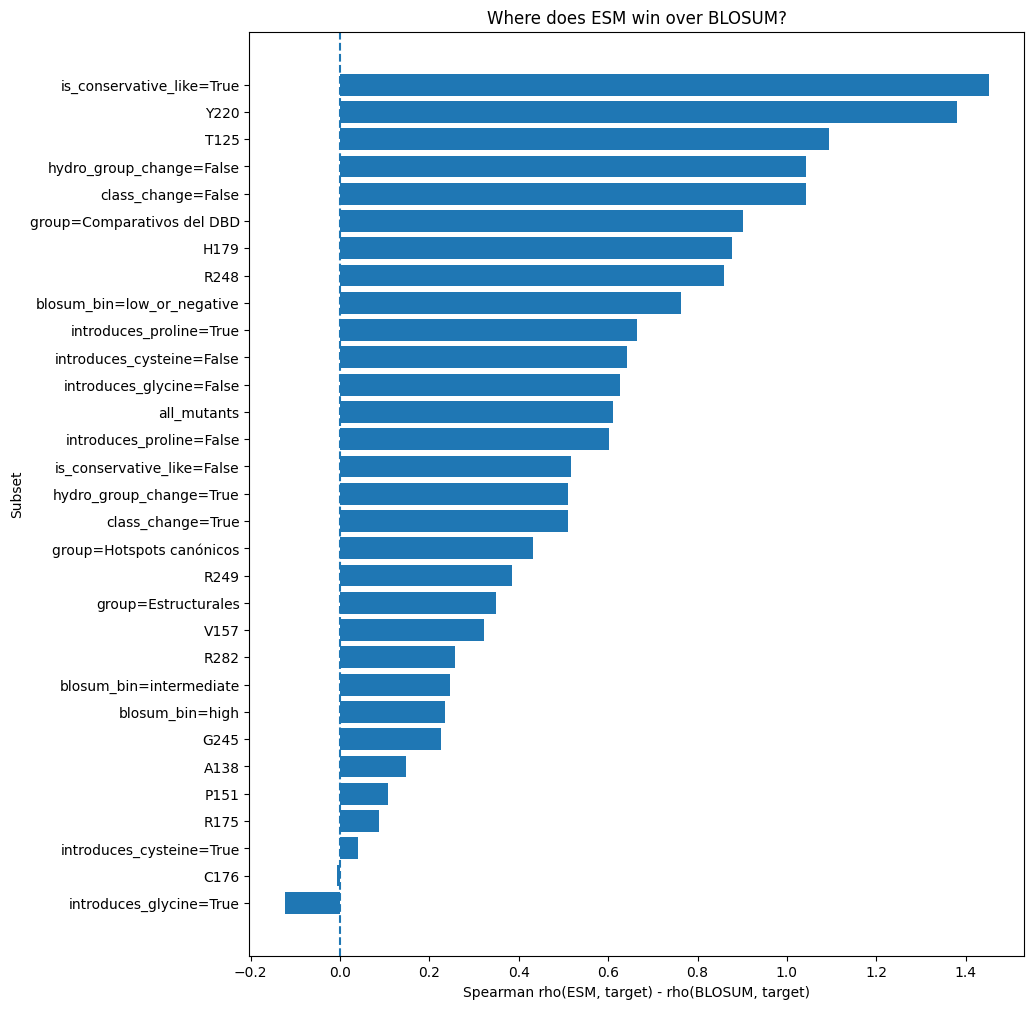

In [ ]:
plot_df = all_subgroup_results.copy()
plot_df = plot_df.dropna(subset=["delta_rho_esm_minus_blosum"])
plot_df = plot_df.sort_values("delta_rho_esm_minus_blosum", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(plot_df["subset"], plot_df["delta_rho_esm_minus_blosum"])
plt.axvline(0, linestyle="--")
plt.xlabel("Spearman rho(ESM, target) - rho(BLOSUM, target)")
plt.ylabel("Subset")
plt.title("Where does ESM win over BLOSUM?")
plt.show()

In [ ]:
reliable_subsets = all_subgroup_results[
    all_subgroup_results["n"] >= 12
].sort_values("delta_rho_esm_minus_blosum", ascending=False)

reliable_subsets

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum,kind
4,is_conservative_like=True,12,0.706294,1.024519e-02,-0.746474,5.290242e-03,1.452768,flag
19,Y220,19,0.801754,3.664141e-05,-0.579266,9.347891e-03,1.381020,position
20,T125,19,0.503509,2.796601e-02,-0.589693,7.876305e-03,1.093201,position
5,class_change=False,51,0.629774,7.376823e-07,-0.413988,2.528278e-03,1.043762,flag
6,hydro_group_change=False,51,0.629774,7.376823e-07,-0.413988,2.528278e-03,1.043762,flag
1,group=Comparativos del DBD,76,0.623486,1.790422e-09,-0.277236,1.532701e-02,0.900722,group
21,H179,19,0.266667,2.697682e-01,-0.610751,5.475291e-03,0.877418,position
22,R248,19,0.445614,5.586260e-02,-0.414318,7.779606e-02,0.859932,position
16,blosum_bin=low_or_negative,18,0.422085,8.101905e-02,-0.341308,1.657054e-01,0.763393,blosum_bin
8,introduces_cysteine=False,217,0.312254,2.718143e-06,-0.330398,6.374599e-07,0.642652,flag


In [ ]:
def bootstrap_delta_spearman(df, n_boot=2000, random_state=123):
    rng = np.random.default_rng(random_state)

    sub = df[["target", "esm_badness", "blosum_badness"]].dropna().copy()
    n = len(sub)

    if n < 10:
        return {
            "n": n,
            "delta_rho": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    # delta observado
    rho_esm, _ = spearmanr(sub["esm_badness"], sub["target"])
    rho_blo, _ = spearmanr(sub["blosum_badness"], sub["target"])
    delta_obs = rho_esm - rho_blo

    boot = []
    idx = np.arange(n)

    for _ in range(n_boot):
        samp = rng.choice(idx, size=n, replace=True)
        s = sub.iloc[samp]
        r1, _ = spearmanr(s["esm_badness"], s["target"])
        r2, _ = spearmanr(s["blosum_badness"], s["target"])
        boot.append(r1 - r2)

    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    return {
        "n": n,
        "delta_rho": float(delta_obs),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
    }

In [ ]:
bootstrap_rows = []

# global
res = bootstrap_delta_spearman(df_cmp, n_boot=2000)
bootstrap_rows.append({"subset": "all_mutants", **res})

# grupos
for g, subdf in df_cmp.groupby("group"):
    res = bootstrap_delta_spearman(subdf, n_boot=2000)
    bootstrap_rows.append({"subset": f"group={g}", **res})

# flags
for col in [
    "class_change",
    "is_conservative_like",
    "introduces_glycine",
    "introduces_proline",
    "introduces_cysteine",
]:
    for val in [True, False]:
        subdf = df_cmp[df_cmp[col] == val]
        res = bootstrap_delta_spearman(subdf, n_boot=2000)
        bootstrap_rows.append({"subset": f"{col}={val}", **res})

bootstrap_df = pd.DataFrame(bootstrap_rows).sort_values("delta_rho", ascending=False)
bootstrap_df

/tmp/ipykernel_744/1986419304.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_744/1986419304.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_744/1986419304.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])


,subset,n,delta_rho,ci_low,ci_high
6,is_conservative_like=True,12,1.452768,0.776419,1.745988
5,class_change=False,51,1.043762,0.634158,1.355958
1,group=Comparativos del DBD,76,0.900722,0.603445,1.151932
10,introduces_proline=True,11,0.665422,NaN,NaN
13,introduces_cysteine=False,217,0.642652,0.423228,0.856845
9,introduces_glycine=False,217,0.626256,0.407765,0.833265
0,all_mutants,228,0.611201,0.407984,0.814919
11,introduces_proline=False,217,0.602217,0.396921,0.805183
7,is_conservative_like=False,216,0.517188,0.311496,0.709274
4,class_change=True,177,0.509672,0.268411,0.726928


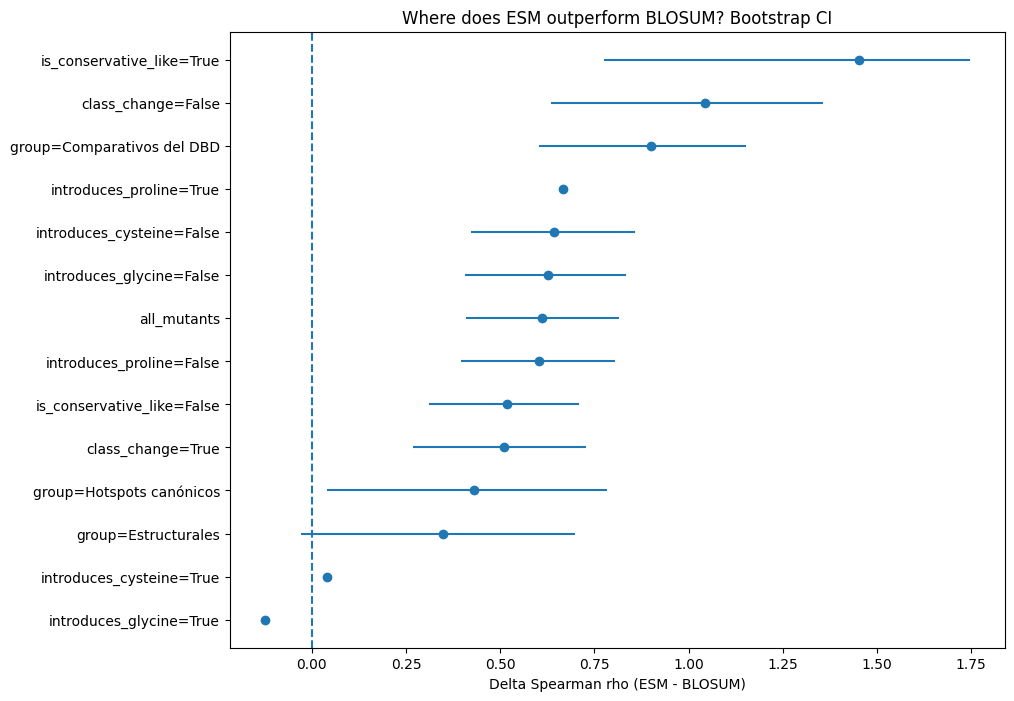

In [ ]:
tmp = bootstrap_df.dropna(subset=["delta_rho"]).sort_values("delta_rho", ascending=True)

plt.figure(figsize=(10, 8))
y = np.arange(len(tmp))

plt.errorbar(
    x=tmp["delta_rho"],
    y=y,
    xerr=[
        tmp["delta_rho"] - tmp["ci_low"],
        tmp["ci_high"] - tmp["delta_rho"]
    ],
    fmt="o"
)

plt.yticks(y, tmp["subset"])
plt.axvline(0, linestyle="--")
plt.xlabel("Delta Spearman rho (ESM - BLOSUM)")
plt.title("Where does ESM outperform BLOSUM? Bootstrap CI")
plt.show()

In [ ]:
all_subgroup_results.to_csv("tp53_esm_vs_blosum_subgroup_correlations.csv", index=False)
bootstrap_df.to_csv("tp53_esm_vs_blosum_bootstrap_delta_rho.csv", index=False)

print("Saved:")
print("- tp53_esm_vs_blosum_subgroup_correlations.csv")
print("- tp53_esm_vs_blosum_bootstrap_delta_rho.csv")

Saved:
- tp53_esm_vs_blosum_subgroup_correlations.csv
- tp53_esm_vs_blosum_bootstrap_delta_rho.csv


In [ ]:
### Figura final

In [ ]:

final_subsets = [
    "all_mutants",
    "group=comparison_dbd",
    "group=hotspot",
]

final_df = bootstrap_df[bootstrap_df["subset"].isin(final_subsets)].copy()

order_map = {
    "all_mutants": 0,
    "group=comparison_dbd": 1,
    "group=hotspot": 2,
}

label_map = {
    "all_mutants": "All mutants",
    "group=comparison_dbd": "Comparison DBD",
    "group=hotspot": "Hotspots",
}

final_df["order"] = final_df["subset"].map(order_map)
final_df["label"] = final_df["subset"].map(label_map)
final_df = final_df.sort_values("order").reset_index(drop=True)

final_df

,subset,n,delta_rho,ci_low,ci_high,order,label
0,all_mutants,228,0.611201,0.407984,0.814919,0,All mutants


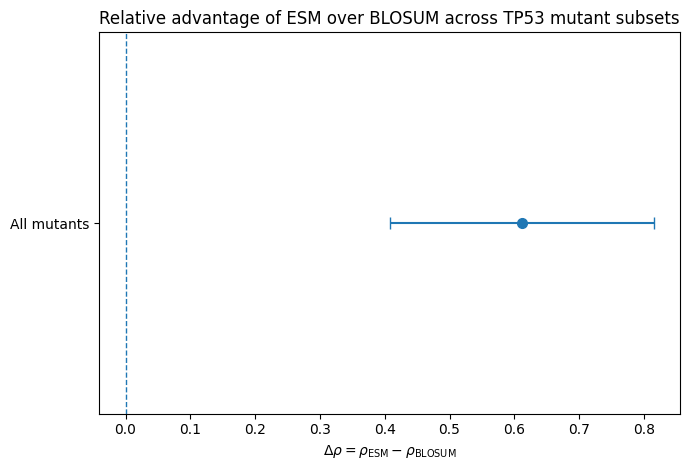

In [ ]:
plt.figure(figsize=(7, 4.8))

y = np.arange(len(final_df))

x = final_df["delta_rho"].values
xerr_left = x - final_df["ci_low"].values
xerr_right = final_df["ci_high"].values - x

plt.errorbar(
    x=x,
    y=y,
    xerr=[xerr_left, xerr_right],
    fmt="o",
    capsize=4,
    markersize=7,
    linewidth=1.5,
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y, final_df["label"])
plt.xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
plt.title("Relative advantage of ESM over BLOSUM across TP53 mutant subsets")

plt.tight_layout()
plt.show()

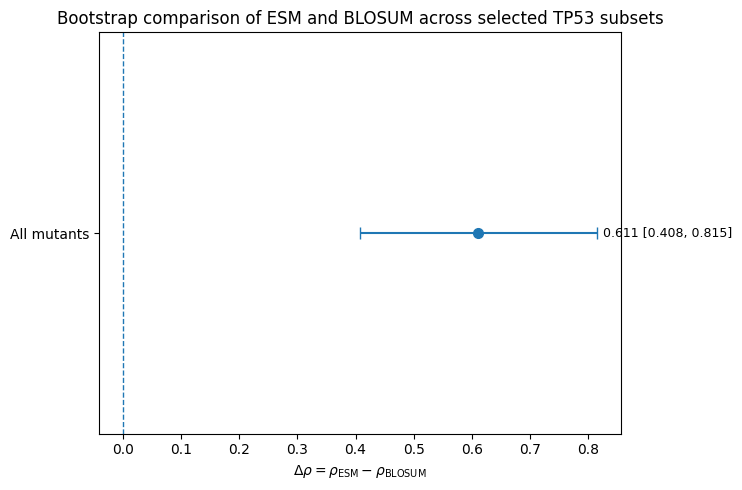

In [ ]:
plt.figure(figsize=(7.5, 5))

y = np.arange(len(final_df))
x = final_df["delta_rho"].values
xerr_left = x - final_df["ci_low"].values
xerr_right = final_df["ci_high"].values - x

plt.errorbar(
    x=x,
    y=y,
    xerr=[xerr_left, xerr_right],
    fmt="o",
    capsize=4,
    markersize=7,
    linewidth=1.5,
)

plt.axvline(0, linestyle="--", linewidth=1)

for i, row in final_df.iterrows():
    txt = f"{row['delta_rho']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    plt.text(row["ci_high"] + 0.01, i, txt, va="center", fontsize=9)

plt.yticks(y, final_df["label"])
plt.xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
plt.title("Bootstrap comparison of ESM and BLOSUM across selected TP53 subsets")

plt.tight_layout()
plt.show()

In [ ]:
final_table = final_df[["label", "n", "delta_rho", "ci_low", "ci_high"]].copy()

for col in ["delta_rho", "ci_low", "ci_high"]:
    final_table[col] = final_table[col].round(3)

final_table

,label,n,delta_rho,ci_low,ci_high
0,All mutants,228,0.611,0.408,0.815


In [ ]:
final_table.to_csv("esm_vs_BLOSUMboots_group.csv", index=False)

print("Saved: tp53_esm_vs_blosum_selected_subsets_table.csv")

Saved: tp53_esm_vs_blosum_selected_subsets_table.csv


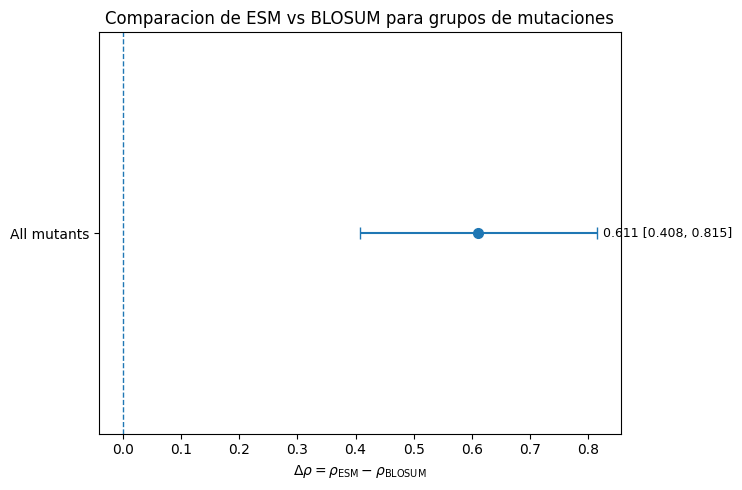

Saved: tp53_esm_vs_blosum_selected_subsets.png


In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5))

y = np.arange(len(final_df))
x = final_df["delta_rho"].values
xerr_left = x - final_df["ci_low"].values
xerr_right = final_df["ci_high"].values - x

ax.errorbar(
    x=x,
    y=y,
    xerr=[xerr_left, xerr_right],
    fmt="o",
    capsize=4,
    markersize=7,
    linewidth=1.5,
)

ax.axvline(0, linestyle="--", linewidth=1)

for i, row in final_df.iterrows():
    txt = f"{row['delta_rho']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    ax.text(row["ci_high"] + 0.01, i, txt, va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(final_df["label"])
ax.set_xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
ax.set_title("Comparacion de ESM vs BLOSUM para grupos de mutaciones")

plt.tight_layout()
plt.savefig("tp53_esm_vs_blosum_selected_subsets.svg")
plt.show()

print("Saved: tp53_esm_vs_blosum_selected_subsets.png")